<div align="center">
  <h1>Airline Route Investment & Profitability Analytics </h1>
</div>


<h2 style="text-align:left;"> Importing Required Libraries </h2>


In [1]:
from pathlib import Path
! pip install tabulate             # For printing tabular data in a clean format (used for console-friendly tables)
import pandas as pd               # Pandas: data manipulation and analysis (DataFrames)
import numpy as np                # NumPy: numerical operations, arrays, and math
import matplotlib.pyplot as plt   # Matplotlib: for creating static plots and charts
import seaborn as sns             # Seaborn: high-level API for statistical data visualization (built on matplotlib)
import os                         # OS: to interact with the operating system (e.g., file paths)
! pip install pulp                # Linear programming library for optimization tasks
from pulp import LpProblem, LpMaximize, LpVariable, lpSum  # Core classes/methods from PuLP for optimization modeling
from sklearn.preprocessing import StandardScaler  # Standardize data before clustering or modeling
from sklearn.cluster import KMeans                # KMeans clustering for route segmentation/analysis


ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


<h2 style="text-align:center;"> Loading the Datasets </h2>



In [2]:
# Defininf base and dataset paths
base_path = Path("d:/Capital One/Data Challenge")
data_path = base_path / "Datasets"

# Defining file paths
flights_file = data_path / "Flights.csv"
tickets_file = data_path / "Tickets.csv"
codes_file = data_path / "Airport_Codes.csv"



<h2 style="text-align: left;"> Airport codes Data </h2>

In [3]:
codes_df = pd.read_csv(codes_file)


<h2 style="text-align: left;"> Flights Data </h2>

In [4]:
flights_df = pd.read_csv(flights_file)


C:\Users\SANJAY\AppData\Local\Temp\ipykernel_19156\343159274.py:1: DtypeWarning: Columns (3,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  flights_df = pd.read_csv(flights_file)


<h2 style="text-align: left;"> Tickets Data </h2>

In [5]:
tickets_df = pd.read_csv(tickets_file)

<h1 style="text-align:center;"> Airport Codes Data </h1>


<h2 style="text-align: left;"> Data Inspection </h2>

In [6]:
# Data Inspection Function
def inspect_dataset(df, name="Dataset"):
    print(f"\n📊 Inspecting: {name}")
    print("=" * (13 + len(name)))

    # Preview data (first and last 5 rows)
    print("\n🔹 Preview of the data (head & tail):")
    display(pd.concat([df.head(), df.tail()]).reset_index(drop=True))

    # Shape
    rows, columns = df.shape
    print(f"\n🔹 The dataset contains {rows} rows and {columns} columns.")

    # Column info
    print("\n🔹 Column Data Types:")
    print(df.info())

    # Missing values
    print("\n🔹 Missing Values:")
    print(df.isnull().sum())

    # Unique values per column
    print("\n🔹 Unique Values per Column:")
    print(df.nunique())



In [7]:
# Inspecting the Airport codes dataset  
inspect_dataset(codes_df, name="Airport Codes Dataset")


📊 Inspecting: Airport Codes Dataset

🔹 Preview of the data (head & tail):


,TYPE,NAME,ELEVATION_FT,CONTINENT,ISO_COUNTRY,MUNICIPALITY,IATA_CODE,COORDINATES
0,heliport,Total Rf Heliport,11.0,NaN,US,Bensalem,NaN,"-74.93360137939453, 40.07080078125"
1,small_airport,Aero B Ranch Airport,3435.0,NaN,US,Leoti,NaN,"-101.473911, 38.704022"
2,small_airport,Lowell Field,450.0,NaN,US,Anchor Point,NaN,"-151.695999146, 59.94919968"
3,small_airport,Epps Airpark,820.0,NaN,US,Harvest,NaN,"-86.77030181884766, 34.86479949951172"
4,closed,Newport Hospital & Clinic Heliport,237.0,NaN,US,Newport,NaN,"-91.254898, 35.6087"
5,medium_airport,Yingkou Lanqi Airport,0.0,AS,CN,Yingkou,YKH,"122.3586, 40.542524"
6,medium_airport,Shenyang Dongta Airport,NaN,AS,CN,Shenyang,NaN,"123.49600219726562, 41.784400939941406"
7,heliport,Sealand Helipad,40.0,EU,GB,Sealand,NaN,"1.4825, 51.894444"
8,small_airport,Glorioso Islands Airstrip,11.0,AF,TF,Grande Glorieuse,NaN,"47.296388888900005, -11.584277777799999"
9,small_airport,Satsuma IÅjima Airport,338.0,AS,JP,Mishima-Mura,NaN,"130.270556, 30.784722"



🔹 The dataset contains 55369 rows and 8 columns.

🔹 Column Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55369 entries, 0 to 55368
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TYPE          55369 non-null  object 
 1   NAME          55369 non-null  object 
 2   ELEVATION_FT  48354 non-null  float64
 3   CONTINENT     27526 non-null  object 
 4   ISO_COUNTRY   55122 non-null  object 
 5   MUNICIPALITY  49663 non-null  object 
 6   IATA_CODE     9182 non-null   object 
 7   COORDINATES   55369 non-null  object 
dtypes: float64(1), object(7)
memory usage: 3.4+ MB
None

🔹 Missing Values:
TYPE                0
NAME                0
ELEVATION_FT     7015
CONTINENT       27843
ISO_COUNTRY       247
MUNICIPALITY     5706
IATA_CODE       46187
COORDINATES         0
dtype: int64

🔹 Unique Values per Column:
TYPE                7
NAME            52426
ELEVATION_FT     5478
CONTINENT           6
ISO_COUN

<h2>Observations</h2>
<p>Upon inspecting the dataset, the following interpretations were identified:</p>

  <li><strong>Missing Values:</strong> The <code>IATA_CODE</code> and <code>CONTINENT</code> columns contain null values. These missing entries need to be addressed, either through imputation, placeholder values, or removal depending on their relevance to the analysis.</li>
  <li><strong>Coordinates Column:</strong> The <code>coordinates</code> column combines both latitude and longitude values as a single string. To facilitate geospatial analysis, this column requires cleaning by splitting it into separate <code>latitude</code> and <code>longitude</code> columns.</li>
  <li>The columns <strong>TYPE</strong>, <strong>CONTINENT</strong>, <strong>ISO_COUNTRY</strong>, and <strong>IATA_CODE</strong> contain repeated string values and are suitable for conversion to the <code>category</code> data type.</li>
  <li>Converting these columns improves memory efficiency and speeds up operations like filtering, grouping, and sorting.</li>
  <li>Columns such as <strong>NAME</strong>, <strong>MUNICIPALITY</strong>, and <strong>COORDINATES</strong> are likely to have a high number of unique values and are better left as <code>object</code> type.</li>
  <li>The columns <strong>Continent</strong> and <strong>IATA_CODE</strong> have maximum null values. These missing values need to addressed based on their significance.</li>
  <li>The columns <strong>Continent</strong>, <strong>Type</strong>,  and <strong> Iso_Country</strong> have less unique values. These features can be considered for category datatype.</li>

<p>These findings highlight the need for preliminary data cleaning and preprocessing before proceeding with further analysis.</p>

<h2 style="text-align: left;"> Data Cleaning </h2>

<h3 style="text-align: left;"> Changing column names to lower case </h3>

In [8]:
# Fucntion for changing column names to lower case and replacing spaces with underscores
def standardize_column_names(df, to_case='lower', replace_spaces=True):
    if to_case == 'lower':
        df.columns = [
            col.lower().replace(" ", "_") if replace_spaces else col.lower()
            for col in df.columns
        ]
    elif to_case == 'upper':
        df.columns = [
            col.upper().replace(" ", "_") if replace_spaces else col.upper()
            for col in df.columns
        ]
    else:
        print("Invalid 'to_case' value. Use 'lower' or 'upper'.")
    return df


In [9]:
# Changing column names to lower case
codes_df = standardize_column_names(codes_df, to_case='lower', replace_spaces=True)

<h3 style="text-align: left;"> Datatype Conversion </h3>

In [10]:
#  Converts specified columns in a DataFrame to the required data types
def convert_dtype(df, dtype_map):
    for col, dtype in dtype_map.items():
        if col in df.columns:
            try:
                if dtype == 'numeric' or dtype == 'float64':
                    df[col] = pd.to_numeric(df[col], errors='coerce')
                elif 'datetime' in dtype:
                    df[col] = pd.to_datetime(df[col], errors='coerce')
                else:
                    df[col] = df[col].astype(dtype)
                print(f" Converted '{col}' to {dtype}")
            except Exception as e:
                print(f" Could not convert column '{col}' to {dtype}: {e}")
        else:
            print(f" Column '{col}' not found in DataFrame.")
    return df



<h3 style="text-align: left;"> Datatype Conversion </h3>

In [11]:
# Converting columns to appropriate data types
type_conversion = {
    'type': 'category',
    'iso_country': 'category',
}
# Convert columns to specified data types
codes_df = convert_dtype(codes_df, type_conversion)
# Check updated dtypes
codes_df.dtypes


 Converted 'type' to category
 Converted 'iso_country' to category


type            category
name              object
elevation_ft     float64
continent         object
iso_country     category
municipality      object
iata_code         object
coordinates       object
dtype: object

<h2>Observations</h2>
<p>Converted datatypes of TYPE, CONTINENT AND ISO_COUNTRY TO Category.</p>

<h3 style="text-align: left;"> Handling Coordinates column </h3>
<p> Splitting lattitudes and longitudes and creating two new columns. </p>

In [12]:
# Split the 'COORDINATES' column into 'LONGITUDE' and 'LATITUDE'
def split_coordinates(df, coord_col='coordinates', lon_col='longitude', lat_col='latitude'):
    if coord_col in df.columns:
        coords_split = df[coord_col].str.split(',', expand=True)
        df[lon_col] = coords_split[0].str.strip()
        df[lat_col] = coords_split[1].str.strip()
    else:
        print(f"Column '{coord_col}' not found in DataFrame.")
    return df

# Usage
codes_df = split_coordinates(codes_df)
codes_df.head()


,type,name,elevation_ft,continent,iso_country,municipality,iata_code,coordinates,longitude,latitude
0,heliport,Total Rf Heliport,11.0,NaN,US,Bensalem,NaN,"-74.93360137939453, 40.07080078125",-74.93360137939453,40.07080078125
1,small_airport,Aero B Ranch Airport,3435.0,NaN,US,Leoti,NaN,"-101.473911, 38.704022",-101.473911,38.704022
2,small_airport,Lowell Field,450.0,NaN,US,Anchor Point,NaN,"-151.695999146, 59.94919968",-151.695999146,59.94919968
3,small_airport,Epps Airpark,820.0,NaN,US,Harvest,NaN,"-86.77030181884766, 34.86479949951172",-86.77030181884766,34.86479949951172
4,closed,Newport Hospital & Clinic Heliport,237.0,NaN,US,Newport,NaN,"-91.254898, 35.6087",-91.254898,35.6087


<h3>Observation on Coordinate Splitting</h3>
<p>The <code>COORDINATES</code> column was split into two separate fields based on the standard format used in most datasets and mapping APIs, where the first value represents <strong>longitude</strong> (east-west position ranging from –180 to +180), and the second value represents <strong>latitude</strong> (north-south position ranging from –90 to +90). This convention was followed to correctly extract and label the geographical coordinates.</p>


<h3 style="text-align: left;"> Handling Continent and Elevation columns </h3>
<p> While reviewing the dataset, I noticed that the CONTINENT and ELEVATION columna had a lot of missing values and wasn't really relevant for our U.S.-focused analysis. Since it wouldn't add much value, I decided to remove it to keep things cleaner and more focused. </p>

In [13]:
# Droping Continent and Elevation column.
def drop_columns(df, columns):
    existing_cols = [col for col in columns if col in df.columns]
    missing_cols = set(columns) - set(existing_cols)

    if missing_cols:
        print(f"These columns were not found and were skipped: {missing_cols}")
    
    return df.drop(columns=existing_cols)

# dropping columns
codes_df = drop_columns(codes_df, ['continent', 'elevation_ft','coordinates'])


<h3 style="text-align: left;"> Handling ISO_COUNTRY Column </h3>
<p> Since the column has few missing values, i decide to drop them. </p>

In [14]:
# Function to drop missing values from a DataFrame
def drop_missing(df, columns=None, inplace=False):
    if columns:
        cleaned_df = df.dropna(subset=columns, inplace=inplace)
    else:
        cleaned_df = df.dropna(inplace=inplace)

    if not inplace:
        return cleaned_df

codes_df = drop_missing(codes_df, columns=['iso_country'])

In [15]:
codes_df.isnull().sum()

type                0
name                0
iso_country         0
municipality     5604
iata_code       45971
longitude           0
latitude            0
dtype: int64

In [16]:
# converting data types lattitude and longitude to float
type_conversion = {
    'latitude': 'float',
    'longitude': 'float',
}

codes_df = convert_dtype(codes_df, type_conversion)
codes_df.dtypes

 Converted 'latitude' to float
 Converted 'longitude' to float


type            category
name              object
iso_country     category
municipality      object
iata_code         object
longitude        float64
latitude         float64
dtype: object

<h3 style="text-align: left;"> Filtering US airports </h3>

In [17]:
country = "US"
valid_types=['medium_airport', 'large_airport']
def filter_us_airports(df, country, valid_types):
    filtered_df = df[
        (df['iso_country'] == country) &
        (df['type'].isin(valid_types)) &
        (df['iata_code'].notnull())
    ].copy()

    # Keep only relevant columns
    return filtered_df[['iata_code', 'type', 'iso_country','municipality', 'longitude', 'latitude']]

# Filtering US airports
us_codes= filter_us_airports(codes_df,country,valid_types)


In [18]:
us_codes.head()

,iata_code,type,iso_country,municipality,longitude,latitude
6194,WKK,medium_airport,US,Aleknagik,-158.617996,59.282600
26143,ABE,medium_airport,US,Allentown,-75.440804,40.652100
26144,ABI,medium_airport,US,Abilene,-99.681900,32.411301
26145,ABQ,large_airport,US,Albuquerque,-106.609001,35.040199
26146,ABR,medium_airport,US,Aberdeen,-98.421799,45.449100


<h2>Conclusions</h2>
<p> For data cleaning, I dropped the ISO_COUNTRY rows with missing values since the count was relatively small. I also removed the ELEVATION_FT and CONTINENT columns, as they were either irrelevant to the U.S.-focused analysis or contained a large number of missing values. While many rows were missing IATA_CODE, I chose to retain them to preserve the dataset’s integrity for potential exploratory analysis especially since filtering can be applied later during merging. I also kept the MUNICIPALITY column, as it could be useful for labeling routes in visualizations and adding context to final recommendations. </P> 

<h1 style="text-align:center;"> Flights Data </h1>

<h2 style="text-align: left;"> Data Inspection </h2>

In [19]:
# Inspecting the Flights dataset
inspect_dataset(flights_df, name="Flights Dataset")


📊 Inspecting: Flights Dataset

🔹 Preview of the data (head & tail):


,FL_DATE,OP_CARRIER,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,DEST_AIRPORT_ID,DESTINATION,DEST_CITY_NAME,DEP_DELAY,ARR_DELAY,CANCELLED,AIR_TIME,DISTANCE,OCCUPANCY_RATE
0,2019-03-02,WN,N955WN,4591,14635,RSW,"Fort Myers, FL",11042,CLE,"Cleveland, OH",-8.0,-6.0,0.0,143.0,1025.0,0.970000
1,2019-03-02,WN,N8686A,3231,14635,RSW,"Fort Myers, FL",11066,CMH,"Columbus, OH",1.0,5.0,0.0,135.0,930.0,0.550000
2,2019-03-02,WN,N201LV,3383,14635,RSW,"Fort Myers, FL",11066,CMH,"Columbus, OH",0.0,4.0,0.0,132.0,930.0,0.910000
3,2019-03-02,WN,N413WN,5498,14635,RSW,"Fort Myers, FL",11066,CMH,"Columbus, OH",11.0,14.0,0.0,136.0,930.0,0.670000
4,2019-03-02,WN,N7832A,6933,14635,RSW,"Fort Myers, FL",11259,DAL,"Dallas, TX",0.0,-17.0,0.0,151.0,1005.0,0.620000
5,3/23/19,AA,N903NN,1433,15370,TUL,"Tulsa, OK",11057,CLT,"Charlotte, NC",-9.0,-6.0,0.0,112,****,0.794884
6,3/24/19,AA,N965AN,1433,15370,TUL,"Tulsa, OK",11057,CLT,"Charlotte, NC",-2.0,-1.0,0.0,106,****,0.538399
7,3/25/19,AA,N979NN,1433,15370,TUL,"Tulsa, OK",11057,CLT,"Charlotte, NC",-8.0,-25.0,0.0,106,****,0.955579
8,3/26/19,AA,N872NN,1433,15370,TUL,"Tulsa, OK",11057,CLT,"Charlotte, NC",-9.0,-6.0,0.0,112,****,0.595344
9,3/27/19,AA,N945AN,1433,15370,TUL,"Tulsa, OK",11057,CLT,"Charlotte, NC",-8.0,5.0,0.0,117,****,0.350192



🔹 The dataset contains 1915886 rows and 16 columns.

🔹 Column Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1915886 entries, 0 to 1915885
Data columns (total 16 columns):
 #   Column             Dtype  
---  ------             -----  
 0   FL_DATE            object 
 1   OP_CARRIER         object 
 2   TAIL_NUM           object 
 3   OP_CARRIER_FL_NUM  object 
 4   ORIGIN_AIRPORT_ID  int64  
 5   ORIGIN             object 
 6   ORIGIN_CITY_NAME   object 
 7   DEST_AIRPORT_ID    int64  
 8   DESTINATION        object 
 9   DEST_CITY_NAME     object 
 10  DEP_DELAY          float64
 11  ARR_DELAY          float64
 12  CANCELLED          float64
 13  AIR_TIME           object 
 14  DISTANCE           object 
 15  OCCUPANCY_RATE     float64
dtypes: float64(4), int64(2), object(10)
memory usage: 233.9+ MB
None

🔹 Missing Values:
FL_DATE                  0
OP_CARRIER               0
TAIL_NUM             12156
OP_CARRIER_FL_NUM        0
ORIGIN_AIRPORT_ID        0
ORIGIN      

<h3> Flights Dataset: Summary of Initial Inspection</h3>
<ul>
  <li><strong>Shape:</strong> The dataset contains <strong>1,915,886 rows</strong> and <strong>16 columns</strong> with a mix of object, float, and integer types.</li>
  <li><strong>Data Types:</strong> Columns like <code>AIR_TIME</code> and <code>DISTANCE</code> are stored as objects and should be converted to numeric.</li>
  <li><strong>Missing Values:</strong> Key fields like <code>DEP_DELAY</code>, <code>ARR_DELAY</code>, <code>AIR_TIME</code>, <code>DISTANCE</code>, and <code>OCCUPANCY_RATE</code> have missing values that need to be addressed.</li>
  <li><strong>Cancelled Flights:</strong> The <code>CANCELLED</code> column contains two unique values (0 and 1) and can be used to exclude canceled flights from the analysis.</li>
  <li><strong>Airport Coverage:</strong> The data includes <strong>361 unique airports</strong>, with high variability in delay and occupancy rates valuable for route and performance analysis.</li>
</ul>


<h2 style="text-align: left;"> Data Cleaning </h2>

<h3 style="text-align: left;"> Standardizing the column names </h3>

In [20]:
# Changing column names to lower case`
flights_df  = standardize_column_names(flights_df, to_case='lower', replace_spaces=True) 

<h3 style="text-align: left;"> Data Type Conversion </h3>

In [21]:
# Converting columns to appropriate data types
type_conversion = {
  'distance' : 'numeric',
    'air_time' : 'numeric',
    'cancelled': 'category',
    'fl_date': 'datetime64[ns]'
}
# Convert columns to specified data types
flights_df = convert_dtype(flights_df, type_conversion)

 Converted 'distance' to numeric
 Converted 'air_time' to numeric
 Converted 'cancelled' to category
 Converted 'fl_date' to datetime64[ns]


<h3 style="text-align: left;"> Filtering the data by excluding the cancelled flights </h3>

In [22]:
flights_df = flights_df[flights_df['cancelled'] == 0]
flights_df.head()

,fl_date,op_carrier,tail_num,op_carrier_fl_num,origin_airport_id,origin,origin_city_name,dest_airport_id,destination,dest_city_name,dep_delay,arr_delay,cancelled,air_time,distance,occupancy_rate
0,2019-03-02,WN,N955WN,4591,14635,RSW,"Fort Myers, FL",11042,CLE,"Cleveland, OH",-8.0,-6.0,0.0,143.0,1025.0,0.97
1,2019-03-02,WN,N8686A,3231,14635,RSW,"Fort Myers, FL",11066,CMH,"Columbus, OH",1.0,5.0,0.0,135.0,930.0,0.55
2,2019-03-02,WN,N201LV,3383,14635,RSW,"Fort Myers, FL",11066,CMH,"Columbus, OH",0.0,4.0,0.0,132.0,930.0,0.91
3,2019-03-02,WN,N413WN,5498,14635,RSW,"Fort Myers, FL",11066,CMH,"Columbus, OH",11.0,14.0,0.0,136.0,930.0,0.67
4,2019-03-02,WN,N7832A,6933,14635,RSW,"Fort Myers, FL",11259,DAL,"Dallas, TX",0.0,-17.0,0.0,151.0,1005.0,0.62


<h3 style="text-align: left;"> Handling Missing Values </h3>

In [23]:
# Droppint the missing values
flights_df = drop_missing(flights_df, columns=['dep_delay', 'tail_num', 'arr_delay', 'distance', 'air_time', 'occupancy_rate'])

In [24]:
flights_df.isnull().sum()

fl_date              390
op_carrier             0
tail_num               0
op_carrier_fl_num      0
origin_airport_id      0
origin                 0
origin_city_name       0
dest_airport_id        0
destination            0
dest_city_name         0
dep_delay              0
arr_delay              0
cancelled              0
air_time               0
distance               0
occupancy_rate         0
dtype: int64

In [25]:
flights_df.shape

(1855395, 16)

In [26]:
#Extracting needed data 
origin_info = us_codes[['iata_code', 'type']].rename(columns={'iata_code': 'origin', 'type': 'origin_type'})
dest_info = us_codes[['iata_code', 'type']].rename(columns={'iata_code': 'destination', 'type': 'dest_type'})

#Merging airport info
flights_us = flights_df.merge(origin_info, on='origin', how='inner')
flights_us = flights_us.merge(dest_info, on='destination', how='inner')


<p>
  <strong>Merged airport type data:</strong> Airport classification metadata from <code>us_codes</code> was merged into the <code>flights_df</code> dataset by matching IATA codes for both <code>origin</code> and <code>destination</code> airports. 
  This enrichment step added <code>origin_type</code> and <code>dest_type</code> columns to the dataset, enabling more detailed route-level analysis based on airport categories 
  large and medium.
</p>


In [27]:
flights_us.head()

,fl_date,op_carrier,tail_num,op_carrier_fl_num,origin_airport_id,origin,origin_city_name,dest_airport_id,destination,dest_city_name,dep_delay,arr_delay,cancelled,air_time,distance,occupancy_rate,origin_type,dest_type
0,2019-03-02,WN,N955WN,4591,14635,RSW,"Fort Myers, FL",11042,CLE,"Cleveland, OH",-8.0,-6.0,0.0,143.0,1025.0,0.97,large_airport,large_airport
1,2019-03-02,WN,N8686A,3231,14635,RSW,"Fort Myers, FL",11066,CMH,"Columbus, OH",1.0,5.0,0.0,135.0,930.0,0.55,large_airport,large_airport
2,2019-03-02,WN,N201LV,3383,14635,RSW,"Fort Myers, FL",11066,CMH,"Columbus, OH",0.0,4.0,0.0,132.0,930.0,0.91,large_airport,large_airport
3,2019-03-02,WN,N413WN,5498,14635,RSW,"Fort Myers, FL",11066,CMH,"Columbus, OH",11.0,14.0,0.0,136.0,930.0,0.67,large_airport,large_airport
4,2019-03-02,WN,N7832A,6933,14635,RSW,"Fort Myers, FL",11259,DAL,"Dallas, TX",0.0,-17.0,0.0,151.0,1005.0,0.62,large_airport,large_airport


In [28]:
flights_us.shape

(1823686, 18)

In [29]:
# Checking if all ORIGIN and DESTINATION codes are valid US medium/large airports
filtered_origins = flights_us['origin'].unique()
filtered_destinations = flights_us['destination'].unique()

# Compare against the valid airport codes list
all_valid = set(filtered_origins).union(set(filtered_destinations)).issubset(set(us_codes['iata_code']))

print("All ORIGIN and DESTINATION codes are valid US medium/large airports:", all_valid)


All ORIGIN and DESTINATION codes are valid US medium/large airports: True


<h3 style="text-align: left;"> Dropping Unnecessary Columns </h3>

In [30]:
# Dropping irrelevant columns from flights dataset
flights_us = drop_columns(flights_us, [
    'op_carrier', 
    'tail_num', 
    'op_carrier_fl_num', 
    'origin_airport_id', 
    'dest_airport_id', 
    'cancelled', 
    'air_time'
])


<h3 style="text-align: left;"> Converting case of the column values. </h3>

In [31]:
# Function to convert column case (upper, lower, title)
def convert_column_case(df, column, case='upper'):
    if column in df.columns:
        if case == 'upper':
            df[column] = df[column].str.upper()
        elif case == 'lower':
            df[column] = df[column].str.lower()
        elif case == 'title':
            df[column] = df[column].str.title()
        else:
            print("Invalid case argument. Use 'upper', 'lower', or 'title'.")
    else:
        print(f"Column '{column}' not found in DataFrame.")
    return df


In [32]:
# changing the case of column values to lower case
flights_us = convert_column_case(flights_us, 'origin', case='lower')
flights_us = convert_column_case(flights_us, 'destination', case='lower')

In [33]:
flights_us.head()

,fl_date,origin,origin_city_name,destination,dest_city_name,dep_delay,arr_delay,distance,occupancy_rate,origin_type,dest_type
0,2019-03-02,rsw,"Fort Myers, FL",cle,"Cleveland, OH",-8.0,-6.0,1025.0,0.97,large_airport,large_airport
1,2019-03-02,rsw,"Fort Myers, FL",cmh,"Columbus, OH",1.0,5.0,930.0,0.55,large_airport,large_airport
2,2019-03-02,rsw,"Fort Myers, FL",cmh,"Columbus, OH",0.0,4.0,930.0,0.91,large_airport,large_airport
3,2019-03-02,rsw,"Fort Myers, FL",cmh,"Columbus, OH",11.0,14.0,930.0,0.67,large_airport,large_airport
4,2019-03-02,rsw,"Fort Myers, FL",dal,"Dallas, TX",0.0,-17.0,1005.0,0.62,large_airport,large_airport


<h3> Flights Dataset: Summary of Data Cleaning</h3>
<ul>
  <li>Converted <code>distance</code>, <code>air_time</code>, and <code>fl_date</code> to appropriate data types, and set <code>cancelled</code> as a categorical column.</li>
  <li>Excluded all cancelled flights to focus on valid, operational records.</li>
  <li>Dropped rows with missing values in critical columns: <code>dep_delay</code>, <code>arr_delay</code>, <code>distance</code>, <code>air_time</code>, and <code>occupancy_rate</code>.</li>
  <li>Filtered flights to include only those between valid U.S. medium and large airports using the cleaned <code>us_codes</code> dataset.</li>
  <li>Verified that all <code>origin</code> and <code>destination</code> airport codes in the filtered dataset are valid -✅ check passed.</li>
  <li>Removed irrelevant columns such as <code>op_carrier</code>, <code>tail_num</code>, <code>air_time</code>, and airport IDs to streamline the dataset for route-level analysis.</li>
</ul>


<h1 style="text-align:center;"> Tickets Data </h1>

<h2 style="text-align: left;"> Data Inspection </h2>

In [34]:
# Inspecting the Tickets dataset
inspect_dataset(tickets_df, name="Tickets Dataset")


📊 Inspecting: Tickets Dataset

🔹 Preview of the data (head & tail):


,ITIN_ID,YEAR,QUARTER,ORIGIN,ORIGIN_COUNTRY,ORIGIN_STATE_ABR,ORIGIN_STATE_NM,ROUNDTRIP,REPORTING_CARRIER,PASSENGERS,ITIN_FARE,DESTINATION
0,201912723049,2019,1,ABI,US,TX,Texas,1.0,MQ,1.0,736.0,DAB
1,201912723085,2019,1,ABI,US,TX,Texas,1.0,MQ,1.0,570.0,COS
2,201912723491,2019,1,ABI,US,TX,Texas,1.0,MQ,1.0,564.0,MCO
3,201912723428,2019,1,ABI,US,TX,Texas,1.0,MQ,1.0,345.0,LGA
4,201912723509,2019,1,ABI,US,TX,Texas,0.0,MQ,1.0,309.0,MGM
5,201911284909,2019,1,YAK,US,AK,Alaska,0.0,AS,1.0,244.0,ANC
6,201911284959,2019,1,YAK,US,AK,Alaska,1.0,AS,1.0,371.0,JNU
7,201911284940,2019,1,YAK,US,AK,Alaska,0.0,AS,1.0,271.0,JNU
8,201911284914,2019,1,YAK,US,AK,Alaska,0.0,AS,1.0,603.0,ANC
9,201911284952,2019,1,YAK,US,AK,Alaska,1.0,AS,1.0,299.0,JNU



🔹 The dataset contains 1167285 rows and 12 columns.

🔹 Column Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1167285 entries, 0 to 1167284
Data columns (total 12 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   ITIN_ID            1167285 non-null  int64  
 1   YEAR               1167285 non-null  int64  
 2   QUARTER            1167285 non-null  int64  
 3   ORIGIN             1167285 non-null  object 
 4   ORIGIN_COUNTRY     1167285 non-null  object 
 5   ORIGIN_STATE_ABR   1167285 non-null  object 
 6   ORIGIN_STATE_NM    1167285 non-null  object 
 7   ROUNDTRIP          1167285 non-null  float64
 8   REPORTING_CARRIER  1167285 non-null  object 
 9   PASSENGERS         1165308 non-null  float64
 10  ITIN_FARE          1166325 non-null  object 
 11  DESTINATION        1167285 non-null  object 
dtypes: float64(2), int64(3), object(7)
memory usage: 106.9+ MB
None

🔹 Missing Values:
ITIN_ID                 

<h3> Tickets Dataset: Inspection Summary</h3>
<ul>
  <li>The dataset contains <strong>1,167,285 rows</strong> and <strong>12 columns</strong>.</li>
  <li><code>ITIN_FARE</code> is incorrectly stored as an <code>object</code> and needs conversion to numeric.</li>
  <li>Missing values are present in <code>PASSENGERS</code> (1,977 rows) and <code>ITIN_FARE</code> (960 rows).</li>
  <li>Contains 419 unique origin airports and 410 unique destination airports.</li>
  <li>We'll focus only on records with <code>ROUNDTRIP == 1</code>.</li>
  <li>Data is specific to Q1 2019, as <code>YEAR</code> and <code>QUARTER</code> have only one unique value each.</li>
</ul>


<h2 style="text-align: left;"> Data Cleaning </h2>

<h3 style="text-align: left;"> Filtering the data by including only Roundtrips </h3>

In [35]:
 # Filtering tickets for round trips only
tickets_roundtrip = tickets_df[tickets_df['ROUNDTRIP'] == 1].copy()


In [36]:
tickets_roundtrip.head()

,ITIN_ID,YEAR,QUARTER,ORIGIN,ORIGIN_COUNTRY,ORIGIN_STATE_ABR,ORIGIN_STATE_NM,ROUNDTRIP,REPORTING_CARRIER,PASSENGERS,ITIN_FARE,DESTINATION
0,201912723049,2019,1,ABI,US,TX,Texas,1.0,MQ,1.0,736.0,DAB
1,201912723085,2019,1,ABI,US,TX,Texas,1.0,MQ,1.0,570.0,COS
2,201912723491,2019,1,ABI,US,TX,Texas,1.0,MQ,1.0,564.0,MCO
3,201912723428,2019,1,ABI,US,TX,Texas,1.0,MQ,1.0,345.0,LGA
10,201912723337,2019,1,ABI,US,TX,Texas,1.0,MQ,1.0,1647.0,JAX


<h3 style="text-align: left;"> Handling Missing Values. </h3>

In [37]:
# dropping the missing values
tickets_roundtrip = drop_missing(tickets_roundtrip, columns=['PASSENGERS', 'ITIN_FARE'])  
tickets_roundtrip.isnull().sum()  

ITIN_ID              0
YEAR                 0
QUARTER              0
ORIGIN               0
ORIGIN_COUNTRY       0
ORIGIN_STATE_ABR     0
ORIGIN_STATE_NM      0
ROUNDTRIP            0
REPORTING_CARRIER    0
PASSENGERS           0
ITIN_FARE            0
DESTINATION          0
dtype: int64

<h3 style="text-align: left;"> Removing columns which are not required for analysis. </h3>

In [38]:
# remove unnecessary columns
tickets_roundtrip = drop_columns(tickets_roundtrip,['ITIN_ID', 'YEAR', 'QUARTER', 'ORIGIN_COUNTRY', 'REPORTING_CARRIER', 'ROUNDTRIP', 'ORIGIN_STATE_ABR', 'ORIGIN_STATE_NM'])

In [39]:
tickets_roundtrip.head()

,ORIGIN,PASSENGERS,ITIN_FARE,DESTINATION
0,ABI,1.0,736.0,DAB
1,ABI,1.0,570.0,COS
2,ABI,1.0,564.0,MCO
3,ABI,1.0,345.0,LGA
10,ABI,1.0,1647.0,JAX


<h3 style="text-align: left;"> Datatype Conversion </h3>

In [40]:
# Converting columns to appropriate data types
type_conversion = {
  'ITIN_FARE' : 'float64'}
# Convert columns to specified data types
tickets_roundtrip= convert_dtype(tickets_roundtrip, type_conversion)

 Converted 'ITIN_FARE' to float64


In [41]:
# Dropping rows where ITIN_FARE could not be converted to numeric (e.g., invalid or missing fare values)
tickets_roundtrip.dropna(subset=['ITIN_FARE'], inplace=True)


<h3 style="text-align: left;"> Standardizing the column names </h3>

In [42]:
# Changing column names to lower case`
tickets_roundtrip  = standardize_column_names(tickets_roundtrip, to_case='lower', replace_spaces=True) 

In [43]:
tickets_roundtrip.head()

,origin,passengers,itin_fare,destination
0,ABI,1.0,736.0,DAB
1,ABI,1.0,570.0,COS
2,ABI,1.0,564.0,MCO
3,ABI,1.0,345.0,LGA
10,ABI,1.0,1647.0,JAX


In [44]:
tickets_roundtrip = convert_column_case(tickets_roundtrip, 'origin', case='lower')
tickets_roundtrip = convert_column_case(tickets_roundtrip, 'destination', case='lower')

In [45]:
tickets_roundtrip.head()

,origin,passengers,itin_fare,destination
0,abi,1.0,736.0,dab
1,abi,1.0,570.0,cos
2,abi,1.0,564.0,mco
3,abi,1.0,345.0,lga
10,abi,1.0,1647.0,jax


<h1 style="text-align:center;"> Data Merging </h1>

<h3 style="text-align: left;"> Prepare Flights_us dataset for merging </h3>

<h4>ROUTE_PAIR (Flight_us)</h4>
<p><strong></strong><code>ROUTE_PAIR</code> represents each flight as a one-way route by directly combining the origin and destination in the given direction (e.g., <code>JFK-ATL</code> for a flight from JFK to ATL).</p>


In [46]:
# creating a new column 'ROUTE_PAIR' in the flights_us DataFrame
flights_us['route_pair'] = flights_us['origin'] + '-' + flights_us['destination']


<h4>REVERSE_PAIR</h4>
<p><strong></strong> <code>REVERSE_PAIR</code> flips the direction of the route. If the original route is <code>JFK → ATL</code>, the reverse is <code>ATL → JFK</code>.</p>


In [47]:
# creating a new column 'REVERSE PAIR' in the flights_us DataFrame
flights_us['reverse_pair'] = flights_us['destination'] + '-' + flights_us['origin']


In [48]:
flights_us.head()

,fl_date,origin,origin_city_name,destination,dest_city_name,dep_delay,arr_delay,distance,occupancy_rate,origin_type,dest_type,route_pair,reverse_pair
0,2019-03-02,rsw,"Fort Myers, FL",cle,"Cleveland, OH",-8.0,-6.0,1025.0,0.97,large_airport,large_airport,rsw-cle,cle-rsw
1,2019-03-02,rsw,"Fort Myers, FL",cmh,"Columbus, OH",1.0,5.0,930.0,0.55,large_airport,large_airport,rsw-cmh,cmh-rsw
2,2019-03-02,rsw,"Fort Myers, FL",cmh,"Columbus, OH",0.0,4.0,930.0,0.91,large_airport,large_airport,rsw-cmh,cmh-rsw
3,2019-03-02,rsw,"Fort Myers, FL",cmh,"Columbus, OH",11.0,14.0,930.0,0.67,large_airport,large_airport,rsw-cmh,cmh-rsw
4,2019-03-02,rsw,"Fort Myers, FL",dal,"Dallas, TX",0.0,-17.0,1005.0,0.62,large_airport,large_airport,rsw-dal,dal-rsw


<h4>Identifying Bidirectional Routes</h4>
<p><strong></strong> A bidirectional route means both <code>A → B</code> and <code>B → A</code> flights exist in the data. We find this by identifying common routes in <code>ROUTE_PAIR</code> and <code>REVERSE_PAIR</code>.</p>


In [49]:
# Bidirectional routes
bidirectional_routes = set(flights_us['route_pair']).intersection(set(flights_us['reverse_pair']))
print(f"Number of bidirectional routes: {len(bidirectional_routes)}")


Number of bidirectional routes: 5609


<h4>Filter Only Bidirectional Flights</h4>
<p><strong></strong> We only want to keep flights that belong to routes with flights in both directions  i.e., true round-trip eligible routes.</p>


In [50]:
flights_us = flights_us[flights_us['route_pair'].isin(bidirectional_routes)].copy()


In [51]:
# Checking if all remaining route_pairs are in bidirectional_routes
all_bidirectional = flights_us['route_pair'].isin(bidirectional_routes).all()

print(" All routes in flights_us are bidirectional:", all_bidirectional)


 All routes in flights_us are bidirectional: True


<h4>ROUTE_KEY</h4>
<p><strong></strong> <code>ROUTE_KEY</code> is a direction-agnostic route identifier created by alphabetically sorting and combining the origin and destination airport codes. This ensures that both <code>JFK → ATL</code> and <code>ATL → JFK</code> are treated as a single round-trip route: <code>ATL-JFK</code>.</p>


In [52]:
# defining a function for generating route keys
# This function generates a unique key for each route by sorting the origin and destination airport codes
# alphabetically and joining them with a hyphen. This ensures that the route key is consistent regardless of the order of origin and destination.
def generate_route_key(df, origin_col='origin', destination_col='destination'):
    df['route_key'] = df.apply(
        lambda x: '-'.join(sorted([x[origin_col], x[destination_col]])),
        axis=1
    )
    return df


In [53]:
# Creating ROUTE_KEY by alphabetically sorting origin and destination
flights_us = generate_route_key(flights_us, origin_col='origin', destination_col='destination')
flights_us.head()


,fl_date,origin,origin_city_name,destination,dest_city_name,dep_delay,arr_delay,distance,occupancy_rate,origin_type,dest_type,route_pair,reverse_pair,route_key
0,2019-03-02,rsw,"Fort Myers, FL",cle,"Cleveland, OH",-8.0,-6.0,1025.0,0.97,large_airport,large_airport,rsw-cle,cle-rsw,cle-rsw
1,2019-03-02,rsw,"Fort Myers, FL",cmh,"Columbus, OH",1.0,5.0,930.0,0.55,large_airport,large_airport,rsw-cmh,cmh-rsw,cmh-rsw
2,2019-03-02,rsw,"Fort Myers, FL",cmh,"Columbus, OH",0.0,4.0,930.0,0.91,large_airport,large_airport,rsw-cmh,cmh-rsw,cmh-rsw
3,2019-03-02,rsw,"Fort Myers, FL",cmh,"Columbus, OH",11.0,14.0,930.0,0.67,large_airport,large_airport,rsw-cmh,cmh-rsw,cmh-rsw
4,2019-03-02,rsw,"Fort Myers, FL",dal,"Dallas, TX",0.0,-17.0,1005.0,0.62,large_airport,large_airport,rsw-dal,dal-rsw,dal-rsw


<h4>Grouping Flights data by Route Key</h4>

In [54]:
# Grouping flights data by route_key
flights_grouped = flights_us.groupby('route_key').agg({
    'dep_delay': 'mean',
    'arr_delay': 'mean',           
    'distance': 'mean',           # Average one-way distance
    'occupancy_rate': 'mean',
    'origin': 'count'             # Total number of flights (legs)
}).rename(columns={
    'dep_delay': 'avg_dep_delay',
    'arr_delay': 'avg_arr_delay',
    'distance': 'avg_distance',
    'occupancy_rate': 'avg_occupancy_rate',
    'origin': 'total_flight_legs'
}).reset_index()


<h4>Merging Airport Metadata</h4>
<p>
After grouping flight data by <code>route_key</code>, essential metadata like <code>origin_type</code>, <code>dest_type</code>, and city names were no longer available. 
To restore this information, i created a mapping from <code>flights_us</code> and merged it back into the grouped DataFrame. 
This step ensured that airport types (for fee calculation) and city names (for visualization and reporting) were included in the final dataset.
</p>

In [55]:
# airport_type_map is a DataFrame that maps each route_key to its corresponding origin and destination types
airport_type_map = flights_us[['route_key', 'origin_type', 'dest_type','origin_city_name','dest_city_name']].drop_duplicates(subset='route_key')
airport_type_map

,route_key,origin_type,dest_type,origin_city_name,dest_city_name
0,cle-rsw,large_airport,large_airport,"Fort Myers, FL","Cleveland, OH"
1,cmh-rsw,large_airport,large_airport,"Fort Myers, FL","Columbus, OH"
4,dal-rsw,large_airport,large_airport,"Fort Myers, FL","Dallas, TX"
5,grr-rsw,large_airport,medium_airport,"Fort Myers, FL","Grand Rapids, MI"
6,ind-rsw,large_airport,large_airport,"Fort Myers, FL","Indianapolis, IN"
...,...,...,...,...,...
1550546,lga-mtj,large_airport,medium_airport,"New York, NY","Montrose/Delta, CO"
1568543,bhm-sjc,large_airport,large_airport,"San Jose, CA","Birmingham, AL"
1796083,mtj-slc,medium_airport,large_airport,"Montrose/Delta, CO","Salt Lake City, UT"
1798152,ege-slc,medium_airport,large_airport,"Eagle, CO","Salt Lake City, UT"


In [56]:
# Merging the airport type information into the grouped DataFrame
flights_grouped = flights_grouped.merge(airport_type_map, on='route_key', how='left')


<h4>Inspecting grouped flights dataframe.</h4>

In [57]:
# Inspecting the grouped flights data
inspect_dataset(flights_grouped, name="Grouped Flights Dataset")


📊 Inspecting: Grouped Flights Dataset

🔹 Preview of the data (head & tail):


,route_key,avg_dep_delay,avg_arr_delay,avg_distance,avg_occupancy_rate,total_flight_legs,origin_type,dest_type,origin_city_name,dest_city_name
0,abe-atl,6.873272,2.557604,692.0,0.654332,434,large_airport,medium_airport,"Atlanta, GA","Allentown/Bethlehem/Easton, PA"
1,abe-clt,3.838645,1.468127,481.0,0.661096,502,medium_airport,large_airport,"Allentown/Bethlehem/Easton, PA","Charlotte, NC"
2,abe-dtw,13.697581,5.981855,425.0,0.644919,496,medium_airport,large_airport,"Allentown/Bethlehem/Easton, PA","Detroit, MI"
3,abe-fll,5.400000,4.250000,1041.0,0.605250,40,medium_airport,large_airport,"Allentown/Bethlehem/Easton, PA","Fort Lauderdale, FL"
4,abe-ord,28.990566,23.666667,654.0,0.649434,318,medium_airport,large_airport,"Allentown/Bethlehem/Easton, PA","Chicago, IL"
5,stl-tpa,11.326190,5.073810,869.0,0.657762,420,large_airport,large_airport,"St. Louis, MO","Tampa, FL"
6,stl-tul,6.033951,0.265432,351.0,0.647284,324,large_airport,large_airport,"St. Louis, MO","Tulsa, OK"
7,syr-tpa,22.486111,9.500000,1104.0,0.615556,72,large_airport,large_airport,"Tampa, FL","Syracuse, NY"
8,tpa-ttn,15.044872,7.557692,955.0,0.637756,156,medium_airport,large_airport,"Trenton, NJ","Tampa, FL"
9,vps-xna,20.360000,24.760000,601.0,0.605600,25,large_airport,medium_airport,"Valparaiso, FL","Fayetteville, AR"



🔹 The dataset contains 2805 rows and 10 columns.

🔹 Column Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2805 entries, 0 to 2804
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   route_key           2805 non-null   object  
 1   avg_dep_delay       2805 non-null   float64 
 2   avg_arr_delay       2805 non-null   float64 
 3   avg_distance        2805 non-null   float64 
 4   avg_occupancy_rate  2805 non-null   float64 
 5   total_flight_legs   2805 non-null   int64   
 6   origin_type         2805 non-null   category
 7   dest_type           2805 non-null   category
 8   origin_city_name    2805 non-null   object  
 9   dest_city_name      2805 non-null   object  
dtypes: category(2), float64(4), int64(1), object(3)
memory usage: 181.6+ KB
None

🔹 Missing Values:
route_key             0
avg_dep_delay         0
avg_arr_delay         0
avg_distance          0
avg_occupancy_rate    0


<p><strong>Note:</strong> Some routes have an odd number of flight legs due to scheduling imbalances (e.g., 3 JFK→ATL flights, 2 ATL→JFK). These unmatched legs were retained to preserve data integrity and completeness. The number of complete round trips was calculated as <code>total_flight_legs // 2</code>, while the remaining unmatched flights were acknowledged and documented as a data management consideration.</p>


<h4>Calculating Round-Trip Distance and Round Trip Count</h4>

In [58]:
# Create round-trip distance by doubling the one-way average distance
flights_grouped['round_trip_distance'] = flights_grouped['avg_distance'] * 2

# Calculate round trips from total flight legs
flights_grouped['round_trips'] = flights_grouped['total_flight_legs'] // 2


<h3 style="text-align: left;"> Prepare tickets_roundtrip dataset for merging </h3>

<h4>ROUTE_KEY</h4>

In [59]:
# Creating ROUTE_KEY by alphabetically sorting origin and destination

tickets_roundtrip = generate_route_key(tickets_roundtrip, origin_col='origin', destination_col='destination')

In [60]:
tickets_roundtrip.head()

,origin,passengers,itin_fare,destination,route_key
0,abi,1.0,736.0,dab,abi-dab
1,abi,1.0,570.0,cos,abi-cos
2,abi,1.0,564.0,mco,abi-mco
3,abi,1.0,345.0,lga,abi-lga
10,abi,1.0,1647.0,jax,abi-jax



<h4>Grouping tickets data by route key.</h4>

In [61]:
# Grouping tickets data by route_key
tickets_grouped = tickets_roundtrip.groupby('route_key').agg({
    'passengers': 'sum',
    'itin_fare': 'mean'
}).rename(columns={
    'passengers': 'total_passengers',
    'itin_fare': 'avg_itin_fare'
}).reset_index()


<h4>Inspecting the grouped tickets data.</h4>

In [62]:
# inspecting the grouped tickets data
inspect_dataset(tickets_grouped, name="Grouped Tickets Dataset")


📊 Inspecting: Grouped Tickets Dataset

🔹 Preview of the data (head & tail):


,route_key,total_passengers,avg_itin_fare
0,abe-abi,2.0,758.000000
1,abe-abq,2.0,534.000000
2,abe-ags,3.0,391.000000
3,abe-ama,1.0,654.000000
4,abe-ase,2.0,742.000000
5,vld-xna,6.0,778.666667
6,vps-xna,30.0,270.900000
7,vps-yum,1.0,796.000000
8,wrg-yak,2.0,745.000000
9,xna-ykm,1.0,461.000000



🔹 The dataset contains 25898 rows and 3 columns.

🔹 Column Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25898 entries, 0 to 25897
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   route_key         25898 non-null  object 
 1   total_passengers  25898 non-null  float64
 2   avg_itin_fare     25898 non-null  float64
dtypes: float64(2), object(1)
memory usage: 607.1+ KB
None

🔹 Missing Values:
route_key           0
total_passengers    0
avg_itin_fare       0
dtype: int64

🔹 Unique Values per Column:
route_key           25898
total_passengers      977
avg_itin_fare       13930
dtype: int64


<h4>Dataset Size Comparison: Flights vs. Tickets</h4>
<p><strong>Observation:</strong> After grouping, <code>tickets_grouped</code> contains <strong>25,898</strong> rows, while <code>flights_grouped</code> contains only <strong>2,805</strong> rows.</p>

<p><strong>Explanation:</strong></p>
<ul>
  <li><code>flights_grouped</code> was created from a filtered dataset that includes only U.S. domestic flights between medium and large airports, and only routes that are bidirectional (i.e., support round-trip travel).</li>
  <li><code>tickets_grouped</code> includes all routes from the original dataset, including international itineraries, or those involving small or non-U.S. airports.</li>
  <li>As a result, many <code>route_key</code> values in <code>tickets_grouped</code> do not have a corresponding entry in <code>flights_grouped</code>, leading to a significant difference in row counts.</li>
</ul>

<p>During the merge operation, we use an <code>inner join</code> to retain only the common <code>route_key</code> values, ensuring alignment between ticket and flight data for valid round-trip U.S. routes.</p>


<h3>Joining Flights and Tickets Data</h3>

In [63]:
# Defining the fucntion to merge the two DataFrames.
def Merging_dataframes(flights_df, tickets_df):
    # Ensure both have 'route_key'
    if 'route_key' not in flights_df.columns or 'route_key' not in tickets_df.columns:
        raise ValueError("Both DataFrames must contain a 'route_key' column.")
    
    # Perform inner merge on route_key
    merged_df = pd.merge(
        flights_df,
        tickets_df,
        on='route_key',
        how='inner'
    )

    return merged_df


In [64]:
# Merging the flights and tickets datasets.
final_df = Merging_dataframes(flights_grouped, tickets_grouped)

<h4>Inspecting the final data.</h4>

In [65]:
# indpecting the final merged dataset
inspect_dataset(final_df, name="Final Merged Dataset")


📊 Inspecting: Final Merged Dataset

🔹 Preview of the data (head & tail):


,route_key,avg_dep_delay,avg_arr_delay,avg_distance,avg_occupancy_rate,total_flight_legs,origin_type,dest_type,origin_city_name,dest_city_name,round_trip_distance,round_trips,total_passengers,avg_itin_fare
0,abe-atl,6.873272,2.557604,692.0,0.654332,434,large_airport,medium_airport,"Atlanta, GA","Allentown/Bethlehem/Easton, PA",1384.0,217,94.0,557.141176
1,abe-clt,3.838645,1.468127,481.0,0.661096,502,medium_airport,large_airport,"Allentown/Bethlehem/Easton, PA","Charlotte, NC",962.0,251,51.0,491.135135
2,abe-dtw,13.697581,5.981855,425.0,0.644919,496,medium_airport,large_airport,"Allentown/Bethlehem/Easton, PA","Detroit, MI",850.0,248,99.0,385.809524
3,abe-fll,5.400000,4.250000,1041.0,0.605250,40,medium_airport,large_airport,"Allentown/Bethlehem/Easton, PA","Fort Lauderdale, FL",2082.0,20,100.0,248.734375
4,abe-ord,28.990566,23.666667,654.0,0.649434,318,medium_airport,large_airport,"Allentown/Bethlehem/Easton, PA","Chicago, IL",1308.0,159,39.0,548.354839
5,stl-tpa,11.326190,5.073810,869.0,0.657762,420,large_airport,large_airport,"St. Louis, MO","Tampa, FL",1738.0,210,515.0,376.296820
6,stl-tul,6.033951,0.265432,351.0,0.647284,324,large_airport,large_airport,"St. Louis, MO","Tulsa, OK",702.0,162,95.0,392.350000
7,syr-tpa,22.486111,9.500000,1104.0,0.615556,72,large_airport,large_airport,"Tampa, FL","Syracuse, NY",2208.0,36,131.0,309.974684
8,tpa-ttn,15.044872,7.557692,955.0,0.637756,156,medium_airport,large_airport,"Trenton, NJ","Tampa, FL",1910.0,78,217.0,162.054054
9,vps-xna,20.360000,24.760000,601.0,0.605600,25,large_airport,medium_airport,"Valparaiso, FL","Fayetteville, AR",1202.0,12,30.0,270.900000



🔹 The dataset contains 2776 rows and 14 columns.

🔹 Column Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2776 entries, 0 to 2775
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   route_key            2776 non-null   object  
 1   avg_dep_delay        2776 non-null   float64 
 2   avg_arr_delay        2776 non-null   float64 
 3   avg_distance         2776 non-null   float64 
 4   avg_occupancy_rate   2776 non-null   float64 
 5   total_flight_legs    2776 non-null   int64   
 6   origin_type          2776 non-null   category
 7   dest_type            2776 non-null   category
 8   origin_city_name     2776 non-null   object  
 9   dest_city_name       2776 non-null   object  
 10  round_trip_distance  2776 non-null   float64 
 11  round_trips          2776 non-null   int64   
 12  total_passengers     2776 non-null   float64 
 13  avg_itin_fare        2776 non-null   float64 
dtype

<h4> Removing total_passengers Column</h4>
<p><strong></strong> Based on the project assumptions, each plane holds up to 200 passengers, and instructed not to use the passenger counts from the Tickets data to estimate actual usage.</p>

<p>Since <code>total_passengers</code> comes from the Tickets dataset and isn't meant to be used for calculating revenue or capacity, it's not relevant for our analysis. To keep things clean and aligned with the business rules, this column is fropped from the dataset..</p>


In [66]:
# dropping the total_passengers column
final_df = drop_columns(final_df, ['total_passengers'])


In [67]:
final_df.head()

,route_key,avg_dep_delay,avg_arr_delay,avg_distance,avg_occupancy_rate,total_flight_legs,origin_type,dest_type,origin_city_name,dest_city_name,round_trip_distance,round_trips,avg_itin_fare
0,abe-atl,6.873272,2.557604,692.0,0.654332,434,large_airport,medium_airport,"Atlanta, GA","Allentown/Bethlehem/Easton, PA",1384.0,217,557.141176
1,abe-clt,3.838645,1.468127,481.0,0.661096,502,medium_airport,large_airport,"Allentown/Bethlehem/Easton, PA","Charlotte, NC",962.0,251,491.135135
2,abe-dtw,13.697581,5.981855,425.0,0.644919,496,medium_airport,large_airport,"Allentown/Bethlehem/Easton, PA","Detroit, MI",850.0,248,385.809524
3,abe-fll,5.400000,4.250000,1041.0,0.605250,40,medium_airport,large_airport,"Allentown/Bethlehem/Easton, PA","Fort Lauderdale, FL",2082.0,20,248.734375
4,abe-ord,28.990566,23.666667,654.0,0.649434,318,medium_airport,large_airport,"Allentown/Bethlehem/Easton, PA","Chicago, IL",1308.0,159,548.354839


<h2>Computing Revenue Column</h2>
<p><strong>Assumptions:</strong></p>
<ul>
  <li>Each aircraft has 200 seats.</li>
  <li>Occupancy rate is sourced from the Flights dataset (<code>avg_occupancy</code>).</li>
  <li>Fare per passenger is taken from the Tickets dataset (<code>avg_itin_fare</code>).</li>
  <li>50% of passengers are assumed to check one bag per round trip, generating $70 per person in baggage revenue.</li>
</ul>

<h4>Computing Total Revenue for each Roundtrip</h4>
<p><strong>Formulas Used:</strong></p>
<ul>
  <li><code>est_passengers_per_trip = 200 × avg_occupancy</code></li>
  <li><code>ticket_revenue_per_trip = est_passengers_per_trip × avg_itin_fare</code></li>
  <li><code>baggage_revenue_per_trip = est_passengers_per_trip × 0.5 × 70</code></li>
  <li><code>total_revenue_per_trip = ticket_revenue_per_trip + baggage_revenue_per_trip</code></li>
</ul>

In [68]:
# Step 1: Estimate number of passengers per round trip
final_df['est_passengers_per_trip'] = 200 * final_df['avg_occupancy_rate']

# Step 2: Ticket revenue per round trip
final_df['ticket_revenue_per_trip'] = final_df['est_passengers_per_trip'] * final_df['avg_itin_fare']

# Step 3: Baggage revenue per round trip
final_df['baggage_revenue_per_trip'] = final_df['est_passengers_per_trip'] * 0.5 * 70

# Step 4: Total revenue per round trip
final_df['revenue_per_trip'] = final_df['ticket_revenue_per_trip'] + final_df['baggage_revenue_per_trip']


<h4>Computing Total Revenue for Quarter</h4>

<p><strong>Formula Used:</strong></p>
<ul>
  <li><code>Revenue_quarter = round_trips * revenue_per_trip</code></li>
</ul>

In [69]:
# Total revenue for the entire quarter
final_df['revenue_quarter'] = final_df['revenue_per_trip'] * final_df['round_trips']


<h2>Computing Cost Columns</h2>

<h3>Calculating airport fees</h3>

<h3>Airport Cost Calculation</h3>
<p>
Airport landing fees were calculated based on the type of airport at both the origin and destination. The following rules were applied:
</p>
<ul>
  <li><strong>Medium Airport</strong>: $5,000</li>
  <li><strong>Large Airport</strong>: $10,000</li>
</ul>
<p>
Using these rates, the airport fee per round trip was calculated as:
</p>
<p>
<code>airport_fee_per_trip = origin_fee + dest_fee</code>
</p>
<p>
Here, <code>origin_fee</code> and <code>dest_fee</code> are assigned based on the airport type using a lookup mapping.
</p>


In [70]:
# Setting airport landing fees by type
airport_fee_lookup = {'medium_airport': 5000, 'large_airport': 10000}

# Mapping the airport fees for both origin and destination
final_df['origin_fee'] = final_df['origin_type'].map(airport_fee_lookup)
final_df['dest_fee'] = final_df['dest_type'].map(airport_fee_lookup)

# Airport fee per round trip
final_df['airport_fee_per_trip'] = final_df['origin_fee'] + final_df['dest_fee']

<h3>Calculating delay costs</h3>

<h3>Delay Cost Calculation</h3>
<p>
Delay costs were estimated based on minutes exceeding a 15-minute threshold, as many airports waive short delays. The following logic was used:
</p>

<ul>
  <li><strong>Excess Departure Delay</strong> = max(0, avg_dep_delay − 15)</li>
  <li><strong>Excess Arrival Delay</strong> = max(0, avg_arr_delay − 15)</li>
  <li><strong>Total Delay Minutes per Round Trip</strong> = (excess_dep_delay + excess_arr_delay) × 2</li>
  <li><strong>Delay Cost per Trip</strong> = delay_minutes_per_trip × $75</li>
</ul>

<p>
The multiplier of 2 reflects that each round trip consists of two flight legs. The $75 per minute is an estimated operational cost for delayed time, accounting for crew, fuel, and scheduling impact.
</p>


In [71]:
# Delay costs per round trip (2 legs per round trip)
final_df['excess_dep_delay'] = (final_df['avg_dep_delay'] - 15).clip(lower=0)
final_df['excess_arr_delay'] = (final_df['avg_arr_delay'] - 15).clip(lower=0)
final_df['delay_minutes_per_trip'] = (final_df['excess_dep_delay'] + final_df['excess_arr_delay']) * 2
final_df['delay_cost_per_trip'] = final_df['delay_minutes_per_trip'] * 75

<h3>Calculating distance costs</h3>

<h3>Distance-Based Cost Calculation</h3>
<p>
Fuel, crew, and depreciation costs were calculated based on the total round-trip distance for each route. The following cost assumptions were applied:
</p>

<ul>
  <li><strong>Fuel & Crew Cost per Trip</strong> = round_trip_distance × $8</li>
  <li><strong>Depreciation Cost per Trip</strong> = round_trip_distance × $1.18</li>
</ul>

<p>
These multipliers estimate the variable operating expenses associated with longer routes. The fuel and crew cost reflects direct operating expenses, while depreciation cost accounts for aircraft wear and tear over distance.
</p>


In [72]:
# Distance-based costs
final_df['fuel_crew_cost_per_trip'] = final_df['round_trip_distance'] * 8
final_df['depreciation_cost_per_trip'] = final_df['round_trip_distance'] * 1.18


<h3>Calculating total costs for each roundtrip</h3>

<h3>Total Cost per Round Trip</h3>
<p>
The total operational cost for each round trip was calculated by summing all individual cost components. The formula is as follows:
</p>

<p>
<code>cost_per_trip = fuel_crew_cost_per_trip + depreciation_cost_per_trip + delay_cost_per_trip + airport_fee_per_trip</code>
</p>

<p>
This comprehensive cost includes distance-based expenses (fuel, crew, and depreciation), time-based delay penalties, and fixed airport landing fees, providing a complete view of round-trip operating costs.
</p>


In [73]:
# Total cost per round trip
final_df['cost_per_trip'] = (
    final_df['fuel_crew_cost_per_trip'] +
    final_df['depreciation_cost_per_trip'] +
    final_df['delay_cost_per_trip'] +
    final_df['airport_fee_per_trip'])

<h3>Computing total cost for quarter</h3>

<h3>Total Cost per Quarter</h3>
<p>
To estimate the total operating cost over the entire quarter, the cost per round trip was multiplied by the number of round trips for each route. The formula is:
</p>

<p>
<code>cost_quarter = cost_per_trip × round_trips</code>
</p>

<p>
This gives a quarterly-level view of total expenses incurred for operating each route, including distance-based, delay-related, and airport-specific costs.
</p>


In [74]:
#total cost for the entire quarter
final_df['cost_quarter'] = final_df['cost_per_trip'] * final_df['round_trips']

In [75]:
final_df[['route_key','revenue_per_trip','revenue_quarter','cost_per_trip','cost_quarter']].head()

,route_key,revenue_per_trip,revenue_quarter,cost_per_trip,cost_quarter
0,abe-atl,77491.360043,1.681563e+07,27705.120000,6012011.04
1,abe-clt,69565.126413,1.746085e+07,23831.160000,5981621.16
2,abe-dtw,54277.641321,1.346086e+07,22803.000000,5655144.00
3,abe-fll,34346.046094,6.869209e+05,34112.760000,682255.20
4,abe-ord,75770.088862,1.204744e+07,30406.024906,4834557.96


<h2>Computing profit Columns</h2>

<h4>Computing profits for quarter and each trip</h4>

In [76]:
final_df['profit_per_trip'] = final_df['revenue_per_trip'] - final_df['cost_per_trip']
final_df['profit_quarter'] = final_df['revenue_quarter'] - final_df['cost_quarter']


In [77]:
final_df.head()

,route_key,avg_dep_delay,avg_arr_delay,avg_distance,avg_occupancy_rate,total_flight_legs,origin_type,dest_type,origin_city_name,dest_city_name,...,excess_dep_delay,excess_arr_delay,delay_minutes_per_trip,delay_cost_per_trip,fuel_crew_cost_per_trip,depreciation_cost_per_trip,cost_per_trip,cost_quarter,profit_per_trip,profit_quarter
0,abe-atl,6.873272,2.557604,692.0,0.654332,434,large_airport,medium_airport,"Atlanta, GA","Allentown/Bethlehem/Easton, PA",...,0.000000,0.000000,0.000000,0.000000,11072.0,1633.12,27705.120000,6012011.04,49786.240043,1.080361e+07
1,abe-clt,3.838645,1.468127,481.0,0.661096,502,medium_airport,large_airport,"Allentown/Bethlehem/Easton, PA","Charlotte, NC",...,0.000000,0.000000,0.000000,0.000000,7696.0,1135.16,23831.160000,5981621.16,45733.966413,1.147923e+07
2,abe-dtw,13.697581,5.981855,425.0,0.644919,496,medium_airport,large_airport,"Allentown/Bethlehem/Easton, PA","Detroit, MI",...,0.000000,0.000000,0.000000,0.000000,6800.0,1003.00,22803.000000,5655144.00,31474.641321,7.805711e+06
3,abe-fll,5.400000,4.250000,1041.0,0.605250,40,medium_airport,large_airport,"Allentown/Bethlehem/Easton, PA","Fort Lauderdale, FL",...,0.000000,0.000000,0.000000,0.000000,16656.0,2456.76,34112.760000,682255.20,233.286094,4.665722e+03
4,abe-ord,28.990566,23.666667,654.0,0.649434,318,medium_airport,large_airport,"Allentown/Bethlehem/Easton, PA","Chicago, IL",...,13.990566,8.666667,45.314465,3398.584906,10464.0,1543.44,30406.024906,4834557.96,45364.063956,7.212886e+06


In [78]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2776 entries, 0 to 2775
Data columns (total 31 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   route_key                   2776 non-null   object  
 1   avg_dep_delay               2776 non-null   float64 
 2   avg_arr_delay               2776 non-null   float64 
 3   avg_distance                2776 non-null   float64 
 4   avg_occupancy_rate          2776 non-null   float64 
 5   total_flight_legs           2776 non-null   int64   
 6   origin_type                 2776 non-null   category
 7   dest_type                   2776 non-null   category
 8   origin_city_name            2776 non-null   object  
 9   dest_city_name              2776 non-null   object  
 10  round_trip_distance         2776 non-null   float64 
 11  round_trips                 2776 non-null   int64   
 12  avg_itin_fare               2776 non-null   float64 
 13  est_passengers_per

<h4>Creating a new dataframe for exploratory data analysis</h4>

In [79]:
selected_cols = [
    'route_key',
    'round_trips',
    'avg_occupancy_rate',
    'avg_dep_delay',
    'avg_arr_delay',
    'revenue_quarter',
    'cost_quarter',
    'profit_quarter',
    'revenue_per_trip',
    'cost_per_trip',
    'profit_per_trip',
    'origin_type',
    'dest_type',
    'origin_city_name',
    'dest_city_name'
]
# Filter the DataFrame to include only the selected columns
eda_df = final_df[selected_cols]
eda_df.head()

,route_key,round_trips,avg_occupancy_rate,avg_dep_delay,avg_arr_delay,revenue_quarter,cost_quarter,profit_quarter,revenue_per_trip,cost_per_trip,profit_per_trip,origin_type,dest_type,origin_city_name,dest_city_name
0,abe-atl,217,0.654332,6.873272,2.557604,1.681563e+07,6012011.04,1.080361e+07,77491.360043,27705.120000,49786.240043,large_airport,medium_airport,"Atlanta, GA","Allentown/Bethlehem/Easton, PA"
1,abe-clt,251,0.661096,3.838645,1.468127,1.746085e+07,5981621.16,1.147923e+07,69565.126413,23831.160000,45733.966413,medium_airport,large_airport,"Allentown/Bethlehem/Easton, PA","Charlotte, NC"
2,abe-dtw,248,0.644919,13.697581,5.981855,1.346086e+07,5655144.00,7.805711e+06,54277.641321,22803.000000,31474.641321,medium_airport,large_airport,"Allentown/Bethlehem/Easton, PA","Detroit, MI"
3,abe-fll,20,0.605250,5.400000,4.250000,6.869209e+05,682255.20,4.665722e+03,34346.046094,34112.760000,233.286094,medium_airport,large_airport,"Allentown/Bethlehem/Easton, PA","Fort Lauderdale, FL"
4,abe-ord,159,0.649434,28.990566,23.666667,1.204744e+07,4834557.96,7.212886e+06,75770.088862,30406.024906,45364.063956,medium_airport,large_airport,"Allentown/Bethlehem/Easton, PA","Chicago, IL"


<h1 style="text-align:center;"> Exploratory Data Analysis </h1>

<h2> Dataset Overview </h2>


In [80]:
# Overview of the dataset
eda_df.info()
eda_df = pd.DataFrame(eda_df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2776 entries, 0 to 2775
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   route_key           2776 non-null   object  
 1   round_trips         2776 non-null   int64   
 2   avg_occupancy_rate  2776 non-null   float64 
 3   avg_dep_delay       2776 non-null   float64 
 4   avg_arr_delay       2776 non-null   float64 
 5   revenue_quarter     2776 non-null   float64 
 6   cost_quarter        2776 non-null   float64 
 7   profit_quarter      2776 non-null   float64 
 8   revenue_per_trip    2776 non-null   float64 
 9   cost_per_trip       2776 non-null   float64 
 10  profit_per_trip     2776 non-null   float64 
 11  origin_type         2776 non-null   category
 12  dest_type           2776 non-null   category
 13  origin_city_name    2776 non-null   object  
 14  dest_city_name      2776 non-null   object  
dtypes: category(2), float64(9), int64(1), 

<h2> Uni-Variate Analysis </h2>

In [81]:
# Function to plot histograms:
def plot_histogram(data, column, ax, bins=30, color='skyblue', title=None, xlabel=None, ylabel='Count'):
    sns.histplot(data=data, x=column, bins=bins, kde=False, ax=ax, color=color)
    ax.set_title(title or f'{column} Distribution')
    ax.set_xlabel(xlabel or column)
    ax.set_ylabel(ylabel)


<h3> Revenue Distributions </h3>

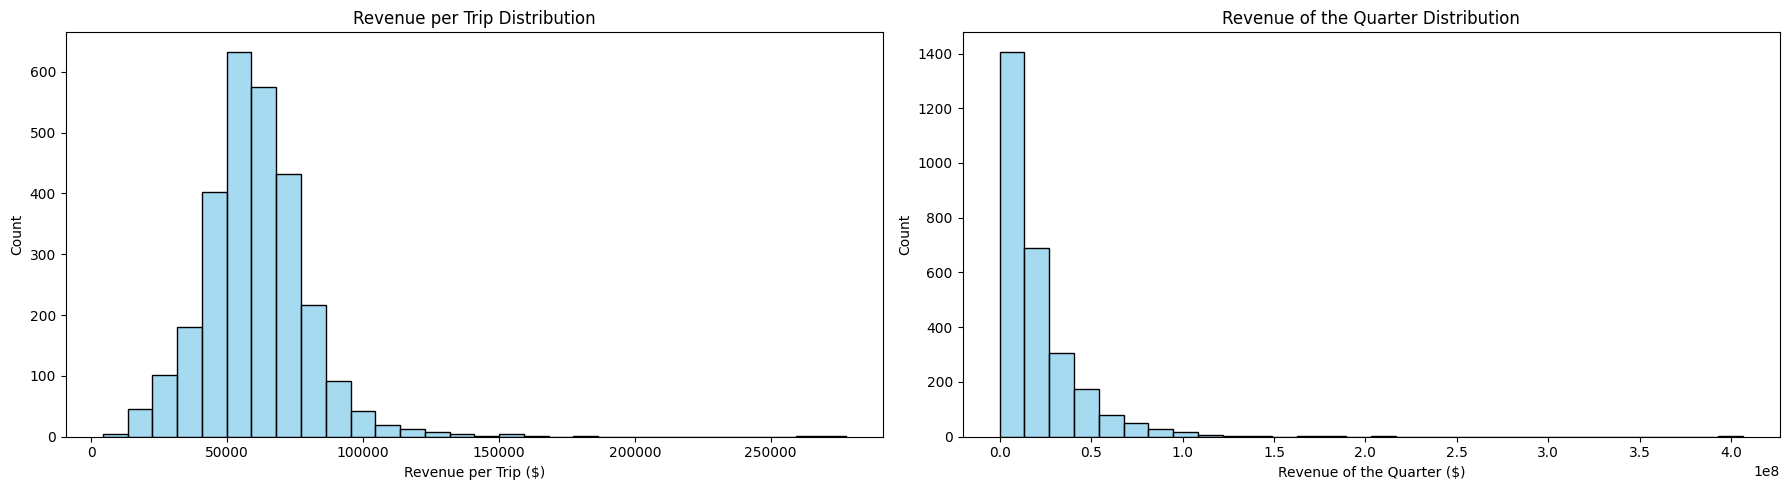

In [82]:
# Set figure size and layout
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Plot 1: Revenue per Trip
plot_histogram(eda_df, 'revenue_per_trip', axes[0], color='skyblue', title='Revenue per Trip Distribution', xlabel='Revenue per Trip ($)')

# Revenue of the quarter
plot_histogram(eda_df, 'revenue_quarter', axes[1], color='skyblue', title='Revenue of the Quarter Distribution', xlabel='Revenue of the Quarter ($)')

# Layout formatting
plt.tight_layout()
plt.show()

<h3>Observations</h3>
<ul>
  <li><b>Revenue per Trip</b> shows a right-skewed distribution, with most trips earning between $30,000 and $70,000.</li>
  <li>A few trips exceed $150,000 in revenue, indicating the presence of outliers.</li>
  <li><b>Revenue of the Quarter</b> is also heavily right-skewed, with most quarters earning below $50 million.</li>
  <li>These distributions suggest the need for log transformation or normalization before applying statistical models.</li>
</ul>

<h3> Cost Distributions </h3>

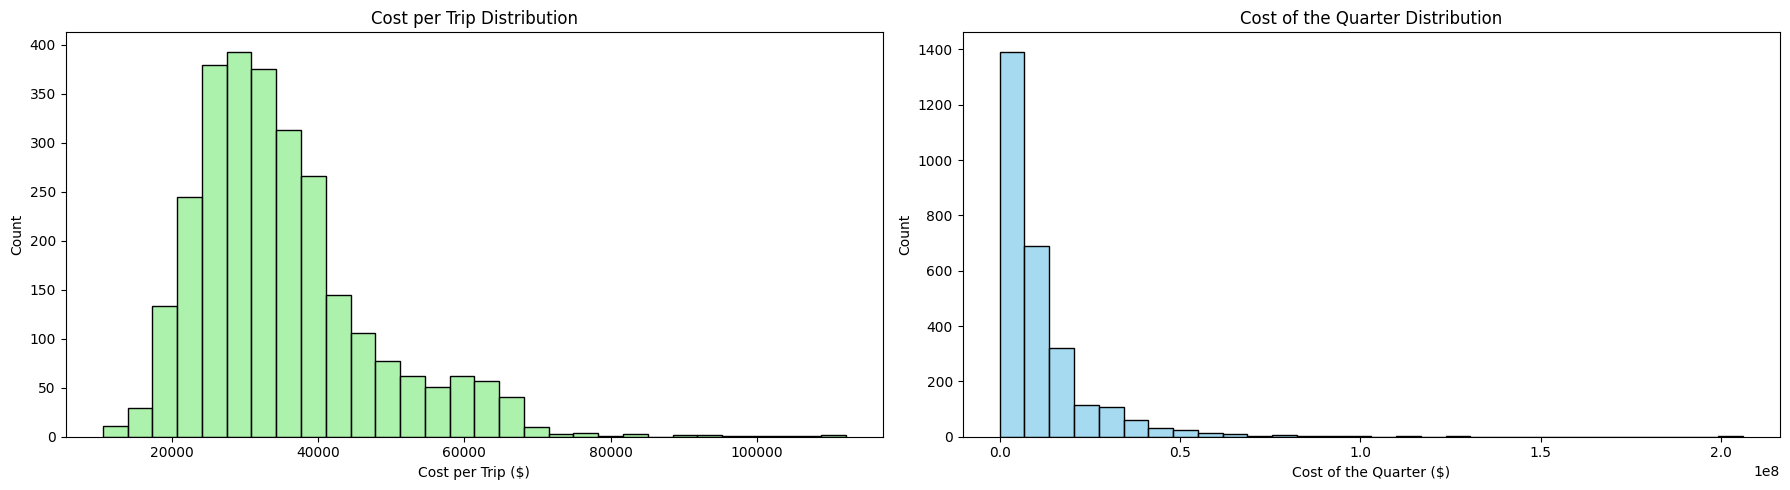

In [83]:
# Set figure size and layout
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
# Plot 2: Cost per Trip
plot_histogram(eda_df, 'cost_per_trip', axes[0], color='lightgreen', title='Cost per Trip Distribution', xlabel='Cost per Trip ($)')

# Plot 1: Cost of the Quarter
plot_histogram(eda_df, 'cost_quarter', axes[1], color='skyblue', title='Cost of the Quarter Distribution', xlabel='Cost of the Quarter ($)')

# Layout formatting
plt.tight_layout()
plt.show()


<h3>Observations</h3>
<ul>
  <li><b>Cost per Trip</b> distribution is right-skewed, with most trips costing between $20,000 and $40,000.</li>
  <li>A small number of trips have costs exceeding $60,000, indicating the presence of outliers.</li>
  <li><b>Cost of the Quarter</b> also shows a strong right-skew, with the majority of quarters having costs under $50 million.</li>
  <li>Both distributions suggest variability in operational costs, which may benefit from normalization in predictive modeling.</li>
</ul>


<h3> Profit Distributions </h3>

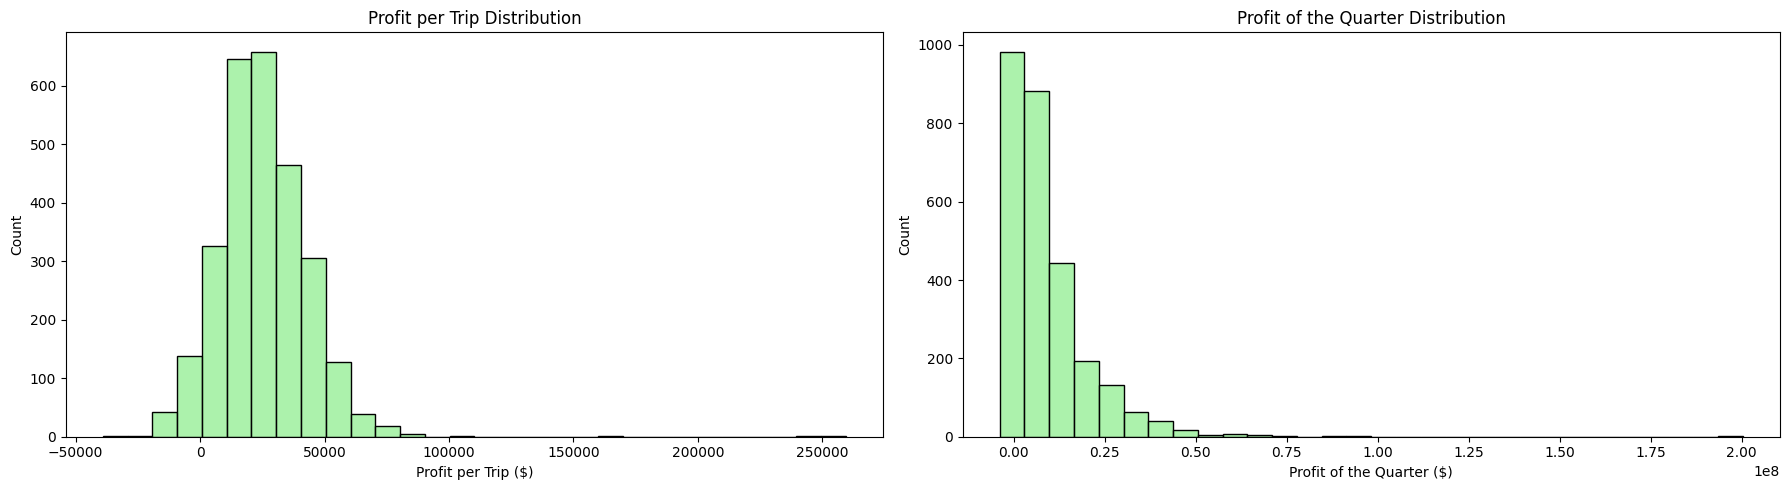

In [84]:
# Set figure size and layout
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
# Plot 2: Profit per Trip
plot_histogram(eda_df, 'profit_per_trip', axes[0], color='lightgreen', title='Profit per Trip Distribution', xlabel='Profit per Trip ($)')

# Plot 3: profit of the Quarter
plot_histogram(eda_df, 'profit_quarter', axes[1], color='lightgreen', title='Profit of the Quarter Distribution', xlabel='Profit of the Quarter ($)')

# Layout formatting
plt.tight_layout()
plt.show()


<h3>Observations</h3>
<ul>
  <li><b>Profit per Trip</b> distribution appears approximately normal with a slight right skew, centered around $20,000 to $40,000.</li>
  <li>Some trips report negative profit, indicating operational losses in certain cases.</li>
  <li><b>Profit of the Quarter</b> shows a strong right-skew, with most values concentrated near zero and a few quarters reporting profits above $50 million.</li>
  <li>This suggests profit fluctuations are common, and modeling may benefit from transformation or segmentation by quarter type.</li>
</ul>


<h2> Bi-Variate Analysis </h2>

<h3> Occuoancy Rate vs Profit Per Trip | Departure Delay vs Cost Per Trip |  Profit per Trip vs Revenue per Trip</h3>

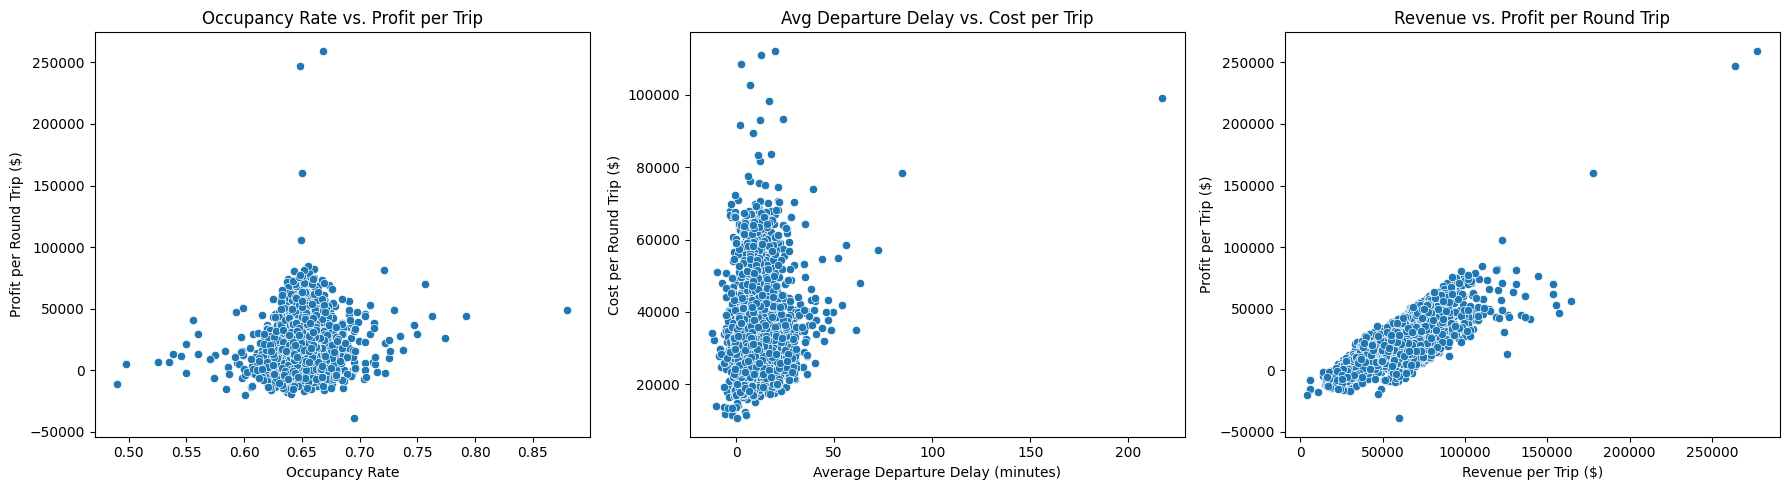

In [85]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Occupancy Rate vs. Profit per Trip
sns.scatterplot(data=eda_df, x='avg_occupancy_rate', y='profit_per_trip', ax=axes[0])
axes[0].set_title('Occupancy Rate vs. Profit per Trip')
axes[0].set_xlabel('Occupancy Rate')
axes[0].set_ylabel('Profit per Round Trip ($)')

# Plot 2: Avg Departure Delay vs. Cost per Trip
sns.scatterplot(data=eda_df, x='avg_dep_delay', y='cost_per_trip', ax=axes[1])
axes[1].set_title('Avg Departure Delay vs. Cost per Trip')
axes[1].set_xlabel('Average Departure Delay (minutes)')
axes[1].set_ylabel('Cost per Round Trip ($)')

# Plot 3: Revenue vs. Profit per Trip
sns.scatterplot(data=eda_df, x='revenue_per_trip', y='profit_per_trip', ax=axes[2])
axes[2].set_title('Revenue vs. Profit per Round Trip')
axes[2].set_xlabel('Revenue per Trip ($)')
axes[2].set_ylabel('Profit per Trip ($)')

plt.tight_layout()
plt.show()





<h3>Observations</h3>
<ul>
  <li><b>Occupancy Rate vs. Profit per Trip:</b> The scatter shows a dense cluster around 0.65 occupancy rate, where most profits lie below $50,000. A few points show significantly higher profits, suggesting better profitability at certain occupancy levels.</li>
  <li><b>Average Departure Delay vs. Cost per Trip:</b> There appears to be no clear linear trend. However, trips with extreme delays can result in higher costs, possibly due to additional operational overhead.</li>
  <li><b>Revenue vs. Profit per Trip:</b> A strong positive relationship is evident as revenue increases, profit tends to increase as well, though some high-revenue trips still yield low or negative profit.</li>
</ul>


<h1 style="text-align:center;"><b> Problem Statement </b> </h1>

<h4>
  <b> 1) Identify the 10 busiest round-trip routes based on the number of round-trip flights operated during the quarter.
  Only valid (non-canceled) flights should be considered in the calculation.</b>
</h4>

In [86]:
eda_df.head()

,route_key,round_trips,avg_occupancy_rate,avg_dep_delay,avg_arr_delay,revenue_quarter,cost_quarter,profit_quarter,revenue_per_trip,cost_per_trip,profit_per_trip,origin_type,dest_type,origin_city_name,dest_city_name
0,abe-atl,217,0.654332,6.873272,2.557604,1.681563e+07,6012011.04,1.080361e+07,77491.360043,27705.120000,49786.240043,large_airport,medium_airport,"Atlanta, GA","Allentown/Bethlehem/Easton, PA"
1,abe-clt,251,0.661096,3.838645,1.468127,1.746085e+07,5981621.16,1.147923e+07,69565.126413,23831.160000,45733.966413,medium_airport,large_airport,"Allentown/Bethlehem/Easton, PA","Charlotte, NC"
2,abe-dtw,248,0.644919,13.697581,5.981855,1.346086e+07,5655144.00,7.805711e+06,54277.641321,22803.000000,31474.641321,medium_airport,large_airport,"Allentown/Bethlehem/Easton, PA","Detroit, MI"
3,abe-fll,20,0.605250,5.400000,4.250000,6.869209e+05,682255.20,4.665722e+03,34346.046094,34112.760000,233.286094,medium_airport,large_airport,"Allentown/Bethlehem/Easton, PA","Fort Lauderdale, FL"
4,abe-ord,159,0.649434,28.990566,23.666667,1.204744e+07,4834557.96,7.212886e+06,75770.088862,30406.024906,45364.063956,medium_airport,large_airport,"Allentown/Bethlehem/Easton, PA","Chicago, IL"


The Top 10 Busiest Round-Trip Routes in the Quarter (Excluding Canceled Flights):


,route_key,round_trips,origin_city_name,dest_city_name,origin_type,dest_type,avg_dep_delay,avg_arr_delay
0,lax-sfo,4166,"San Francisco, CA","Los Angeles, CA",large_airport,large_airport,18.447258,15.709108
1,lga-ord,3573,"New York, NY","Chicago, IL",large_airport,large_airport,21.324517,19.644836
2,las-lax,3253,"Las Vegas, NV","Los Angeles, CA",large_airport,large_airport,10.116508,6.960191
3,jfk-lax,3149,"New York, NY","Los Angeles, CA",large_airport,large_airport,8.508493,-1.890300
4,lax-sea,2496,"Seattle, WA","Los Angeles, CA",large_airport,large_airport,7.744591,4.350561
5,bos-lga,2408,"New York, NY","Boston, MA",large_airport,large_airport,19.614826,14.229028
6,hnl-ogg,2396,"Kahului, HI","Honolulu, HI",medium_airport,large_airport,-0.338410,-0.158356
7,pdx-sea,2385,"Portland, OR","Seattle, WA",large_airport,large_airport,7.580381,7.707399
8,atl-mco,2353,"Atlanta, GA","Orlando, FL",large_airport,large_airport,6.187593,1.407478
9,atl-lga,2294,"Atlanta, GA","New York, NY",large_airport,large_airport,11.289606,5.457834


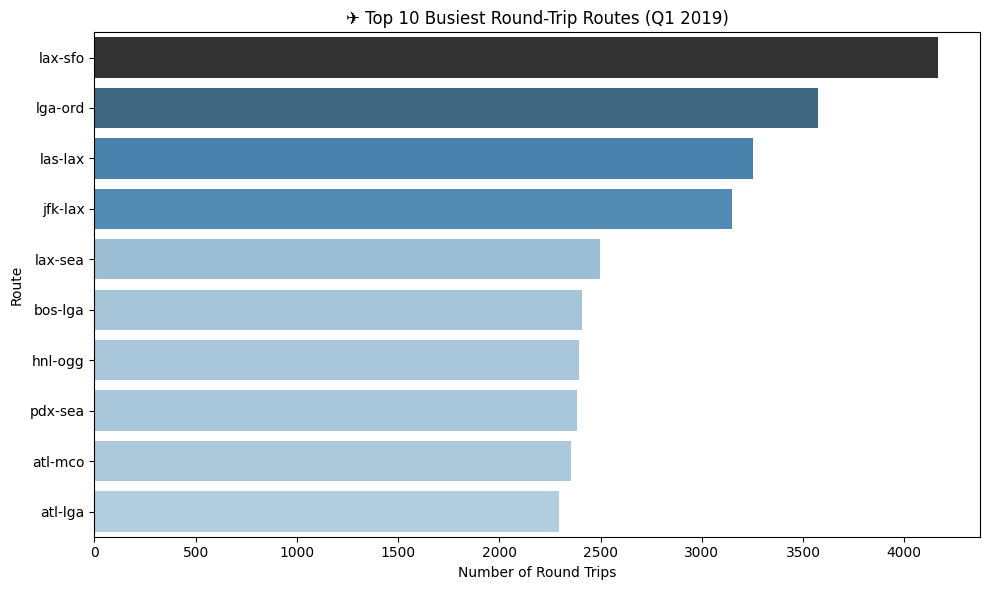

In [87]:
# Get top 10 busiest routes by round trip count
busiest_routes = eda_df[['route_key', 'round_trips','origin_city_name','dest_city_name','origin_type','dest_type','avg_dep_delay','avg_arr_delay']].sort_values(by='round_trips', ascending=False).head(10)

# Optional: reset index for clean display
busiest_routes.reset_index(drop=True, inplace=True)

print("The Top 10 Busiest Round-Trip Routes in the Quarter (Excluding Canceled Flights):")
display(busiest_routes)

plt.figure(figsize=(10, 6))
sns.barplot(x='round_trips', y='route_key', hue='round_trips', data=busiest_routes, palette='Blues_d', legend=False)
plt.title('✈️ Top 10 Busiest Round-Trip Routes (Q1 2019)')
plt.xlabel('Number of Round Trips')
plt.ylabel('Route')
plt.tight_layout()
plt.show()

<h3>Observations</h3>
<ul>
  <li><b>LAX–SFO</b> is the busiest round-trip route in Q1 2019, with over 4,100 flights, significantly ahead of other routes.</li>
  <li>Most top routes connect major metropolitan areas like New York, Los Angeles, Chicago, and San Francisco all serviced by <b>large airports</b>.</li>
  <li>The route <b>HNL–OGG</b> stands out as the only one involving a <b>medium-sized airport</b> (Kahului, HI), highlighting regional demand in Hawaii.</li>
  <li><b>Atlanta (ATL)</b> appears twice as an origin airport, indicating its role as a key hub in the U.S. air travel network.</li>
</ul>


<h4>
  <b> 2) The 10 most profitable round trip routes (without considering the upfront airplane cost) in
 the quarter. Along with the profit, show total revenue, total cost, summary values of
 other key components and total round trip flights in the quarter for the top 10 most
 profitable routes. Exclude canceled flights from these calculations.</b>
</h4>

The Top 10 profitable Round-Trip Routes in the Quarter (Excluding Canceled Flights):


,route_key,profit_quarter,origin_city_name,dest_city_name,origin_type,dest_type,round_trips,profit_per_trip,avg_dep_delay,avg_arr_delay
0,jfk-lax,2.002884e+08,"New York, NY","Los Angeles, CA",large_airport,large_airport,3149,63603.816070,8.508493,-1.890300
1,ewr-sfo,9.179655e+07,"San Francisco, CA","Newark, NJ",large_airport,large_airport,1205,76179.712514,21.443799,14.535462
2,jfk-sfo,8.844071e+07,"San Francisco, CA","New York, NY",large_airport,large_airport,1850,47805.786961,15.151351,6.883784
3,slc-twf,7.525369e+07,"Twin Falls, ID","Salt Lake City, UT",medium_airport,large_airport,290,259495.494044,6.606897,1.118966
4,dca-ord,7.491528e+07,"Washington, DC","Chicago, IL",large_airport,large_airport,1844,40626.505572,10.265456,6.459599
5,dca-lga,7.131490e+07,"Washington, DC","New York, NY",large_airport,large_airport,1678,42499.941892,11.929976,12.023540
6,atl-lga,6.972535e+07,"Atlanta, GA","New York, NY",large_airport,large_airport,2294,30394.661202,11.289606,5.457834
7,lax-sfo,6.713650e+07,"San Francisco, CA","Los Angeles, CA",large_airport,large_airport,4166,16115.337864,18.447258,15.709108
8,bos-lga,6.625116e+07,"New York, NY","Boston, MA",large_airport,large_airport,2408,27512.940353,19.614826,14.229028
9,atl-clt,6.588864e+07,"Atlanta, GA","Charlotte, NC",large_airport,large_airport,1537,42868.339716,5.770007,-0.304164


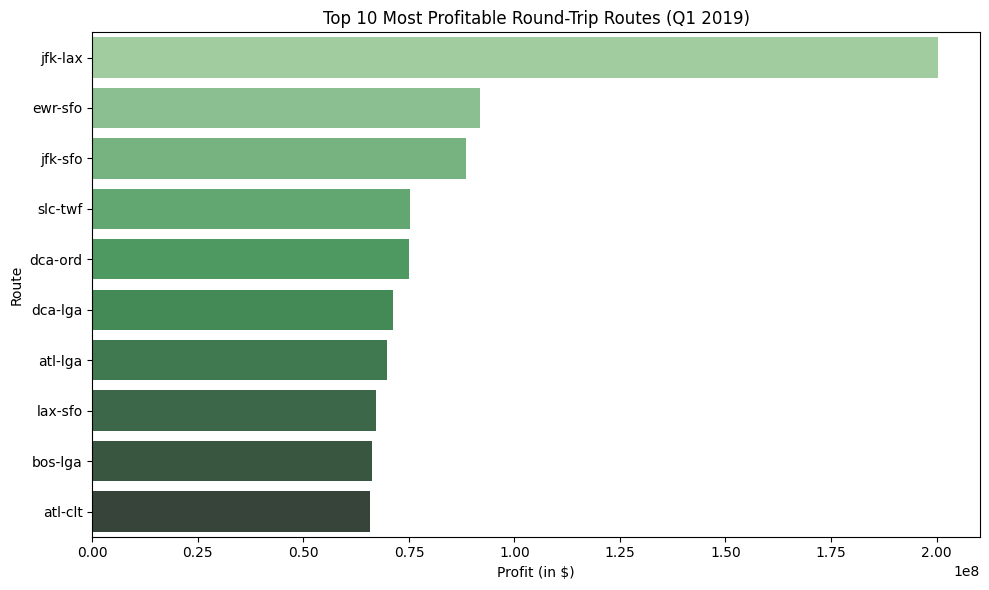

In [88]:
# Select relevant columns for display
profit_cols = [
    'route_key', 'profit_quarter','origin_city_name','dest_city_name','origin_type','dest_type','round_trips','profit_per_trip','avg_dep_delay','avg_arr_delay'
]

# Get top 10 profitable routes
profitable_routes = eda_df[profit_cols].sort_values(by='profit_quarter', ascending=False).head(10).reset_index(drop=True)

# Display table
print("The Top 10 profitable Round-Trip Routes in the Quarter (Excluding Canceled Flights):")
display(profitable_routes)

# Plotting the top 10 profitable routes
plt.figure(figsize=(10, 6))
sns.barplot(
    x='profit_quarter',
    y='route_key',
    hue='route_key',
    data=profitable_routes,
    palette='Greens_d',
    legend=False
)
plt.title('Top 10 Most Profitable Round-Trip Routes (Q1 2019)')
plt.xlabel('Profit (in $)')
plt.ylabel('Route')
plt.tight_layout()
plt.show()


<h3>Observations</h3>
<ul>
  <li><b>JFK–LAX</b> is by far the most profitable route in Q1 2019, generating over $200 million in profit well ahead of all other routes.</li>
  <li>Most profitable routes involve major cities like New York, San Francisco, and Washington, DC, all connected by <b>large airports</b>.</li>
  <li><b>SLC–TWF</b> is the only route involving a <b>medium-sized airport</b> (Twin Falls, ID), indicating regional profitability opportunities.</li>
  <li><b>Atlanta (ATL)</b> and <b>New York (NY)</b> appear frequently, reinforcing their role as major profit-generating hubs in the airline network.</li>
</ul>


<h3>Overlapping the two tables to get top 5 routes:</h3>

In [89]:
# Combine busiest and most profitable routes into one table
combined_df = pd.merge(busiest_routes, profitable_routes, on='route_key')
combined_df.rename(columns={'round_trips_x': 'round_trips'}, inplace=True)

# Rank routes by profit and number of round trips (higher is better)
combined_df['rank_by_profit'] = combined_df['profit_quarter'].rank(ascending=False, method='dense')
combined_df['rank_by_trips'] = combined_df['round_trips'].rank(ascending=False, method='dense')

# Add the two ranks to get a combined score — lower score means better overall rank
combined_df['overall_score'] = combined_df['rank_by_profit'] + combined_df['rank_by_trips']

# Sort by the combined score and pick the top 5 routes
top_5_routes = combined_df.sort_values('overall_score').head(5)

# Show the final result
top_5_routes[['route_key', 'round_trips', 'profit_quarter']]

,route_key,round_trips,profit_quarter
1,jfk-lax,3149,2.002884e+08
0,lax-sfo,4166,6.713650e+07
3,atl-lga,2294,6.972535e+07
2,bos-lga,2408,6.625116e+07


In [90]:
top_5_routes['profit_million'] = top_5_routes['profit_quarter'] / 1e6
top_5_routes['profit_million'] = top_5_routes['profit_million'].map(lambda x: f"${x:,.1f}M")
top_5_routes[['route_key', 'round_trips', 'profit_million']]

,route_key,round_trips,profit_million
1,jfk-lax,3149,$200.3M
0,lax-sfo,4166,$67.1M
3,atl-lga,2294,$69.7M
2,bos-lga,2408,$66.3M


<h3>Drawback of Using Overlapping Routes (Busiest + Profitable)</h3>
<ul>
  <li>While routes like <b>lax-sfo</b>, <b>bos-lga</b>, and <b>atl-lga</b> rank high in traffic, their quarterly profits fall short of recovering the $90M aircraft investment.</li>
  <li><b>lax-sfo</b>, despite being the busiest, only generates ~$67M in profit, which is insufficient for breakeven within one quarter.</li>
  <li>On the other hand, <b>jfk-lax</b> offers over $200M in profit, exceeding the aircraft cost by more than double and ensuring faster ROI.</li>
  <li>Selecting based solely on overlap may prioritize volume over profitability, leading to delayed capital recovery and lower financial efficiency.</li>
</ul>


<h3>Top 5 routes based on profit</h3>

In [91]:
# Assuming your top 10 profitable routes are stored in a DataFrame called profitable_df
top_5_profitable_routes = profitable_routes.sort_values(by='profit_quarter', ascending=False).head(5)

# Optional: Format profit for readability
top_5_profitable_routes['profit_million'] = (top_5_profitable_routes['profit_quarter'] / 1e6).map(lambda x: f"${x:,.1f}M")

# Display
top_5_profitable_routes[['route_key', 'origin_city_name', 'dest_city_name', 'round_trips', 'profit_million','profit_per_trip']]


,route_key,origin_city_name,dest_city_name,round_trips,profit_million,profit_per_trip
0,jfk-lax,"New York, NY","Los Angeles, CA",3149,$200.3M,63603.816070
1,ewr-sfo,"San Francisco, CA","Newark, NJ",1205,$91.8M,76179.712514
2,jfk-sfo,"San Francisco, CA","New York, NY",1850,$88.4M,47805.786961
3,slc-twf,"Twin Falls, ID","Salt Lake City, UT",290,$75.3M,259495.494044
4,dca-ord,"Washington, DC","Chicago, IL",1844,$74.9M,40626.505572


<h3>Justification for Selecting Routes Purely Based on Profit</h3>
<ul>
  <li>To ensure long-term financial sustainability and faster return on investment, we selected the top 5 routes purely based on <b>quarterly profit</b>.</li>
  <li>These routes offer higher <b>profit margins per flight</b> and are more likely to meet the <b>$90M breakeven threshold</b> efficiently.</li>
  <li>By focusing on profitability rather than traffic volume, we better align with the company’s strategy for <b>financial resilience</b> and <b>operational efficiency</b>.</li>
  <li>This approach allows the airline to prioritize strong-performing routes from the outset, reducing early-stage financial risk.</li>
</ul>


<h1><b> Optimisation Model</b> </h1>

In [92]:
cols = [
    'route_key', 'profit_quarter','round_trips','avg_occupancy_rate','avg_arr_delay','avg_dep_delay','profit_per_trip'
]

opt_df = final_df[cols]


In [93]:
opt_df = opt_df.copy()
display(opt_df.head())

,route_key,profit_quarter,round_trips,avg_occupancy_rate,avg_arr_delay,avg_dep_delay,profit_per_trip
0,abe-atl,1.080361e+07,217,0.654332,2.557604,6.873272,49786.240043
1,abe-clt,1.147923e+07,251,0.661096,1.468127,3.838645,45733.966413
2,abe-dtw,7.805711e+06,248,0.644919,5.981855,13.697581,31474.641321
3,abe-fll,4.665722e+03,20,0.605250,4.250000,5.400000,233.286094
4,abe-ord,7.212886e+06,159,0.649434,23.666667,28.990566,45364.063956


In [94]:
# Defining the model
model = LpProblem("Model_1", LpMaximize)

#specifying Binary decision variables for each route
x = {i: LpVariable(f"x_{i}", cat='Binary') for i in opt_df.index}

# Objective function — maximize total profit
model += lpSum(opt_df.loc[i, 'profit_quarter'] * x[i] for i in opt_df.index)

#Applying Constraint — select exactly 5 routes
model += lpSum(x[i] for i in opt_df.index) == 5

# Other Operational constraints
for i in opt_df.index:
    model += opt_df.loc[i, 'avg_occupancy_rate'] * x[i] >= 0.6 * x[i]
    model += opt_df.loc[i, 'avg_arr_delay'] * x[i] <= 15 * x[i]
    model += opt_df.loc[i, 'avg_dep_delay'] * x[i] <= 15 * x[i]
    
#Solving the model
model.solve()

#Extracting the selected routes
selected_routes = opt_df[[x[i].value() == 1 for i in opt_df.index]]

#Displaying results
selected_routes[['route_key', 'profit_quarter', 'round_trips', 'avg_occupancy_rate', 'avg_arr_delay', 'avg_dep_delay']]


,route_key,profit_quarter,round_trips,avg_occupancy_rate,avg_arr_delay,avg_dep_delay
182,atl-lga,6.972535e+07,2294,0.651255,5.457834,11.289606
1094,dca-lga,7.131490e+07,1678,0.652524,12.023540,11.929976
1110,dca-ord,7.491528e+07,1844,0.647834,6.459599,10.265456
1979,jfk-lax,2.002884e+08,3149,0.650040,-1.890300,8.508493
2767,slc-twf,7.525369e+07,290,0.668138,1.118966,6.606897


<h3>Observations – Optimization Model 1 (Profit with Operational Constraints)</h3>
<ul>
  <li><b>Objective:</b> Maximize total quarterly profit by selecting 5 routes from a pool of over 2,500 aggregated round-trip route options.</li>

  <li><b>Constraints applied:</b>
    <ul>
      <li>Exactly 5 routes must be selected.</li>
      <li>Average occupancy rate for selected routes ≥ 60% to ensure efficiency.</li>
      <li>Average arrival and departure delays ≤ 15 minutes to support the airline’s “On time, for you” branding.</li>
    </ul>
  </li>

  <li><b>Input data used:</b> A cleaned and aggregated dataset (<code>opt_df</code>) with columns for quarterly profit, occupancy rate, delays, and flight volume per route.</li>

  <li><b>Output summary:</b> The model selected the following 5 routes that maximize profit while meeting all operational constraints:
    <ul>
      <li><b>JFK–LAX</b> – Highest profit contributor at $200M+ with acceptable delay performance.</li>
      <li><b>SLC–TWF</b> – Excellent on-time performance and profit per flight, despite lower total trips.</li>
      <li><b>ATL–LGA</b>, <b>DCA–LGA</b>, and <b>DCA–ORD</b> – Balanced routes offering moderate to high profits with efficient performance.</li>
    </ul>
  </li>

  <li><b>Business takeaway:</b> These routes collectively provide strong financial performance while staying within operational risk thresholds, making them suitable for initial investment without considering capital recovery at this stage.</li>
</ul>


<h1><b> Weighted Scoring Method(Multi-Criteria Decision Making)</b> </h1>

<h3>Observations – Weighted Scoring Method & Route Selection Logic</h3>
<ul>
  <li>To rank the top 5 routes, a <b>weighted scoring approach</b> was applied, considering profitability, occupancy, flight volume, and operational efficiency.</li>
  <li>Weights were assigned to key metrics: <b>profit (50%)</b>, <b>occupancy rate (20%)</b>, <b>round trips (20%)</b>, and <b>combined delay (10%)</b>.</li>
  <li>An <b>average delay score</b> was created by combining arrival and departure delays and inverting the value to favor low-delay routes.</li>
  <li>Each metric was normalized to ensure equal scale before applying weights, and a final <b>composite score</b> was calculated for each route.</li>
  <li>The top 5 routes selected based on the highest overall score reflect a balanced trade-off between <b>profitability and operational performance</b>, making them strong candidates for market entry.</li>
</ul>


In [95]:
# Assigning weights:
weights = {
    'profit_quarter': 0.5,
    'avg_occupancy_rate': 0.2,
    'round_trips': 0.2,
    'avg_delay_score': 0.1
}

# Creating a delay score
opt_df['avg_delay_score'] = -(opt_df['avg_arr_delay'] + opt_df['avg_dep_delay'])

# Normalizing each metric
for col in ['profit_quarter', 'avg_occupancy_rate', 'round_trips', 'avg_delay_score']:
    opt_df[col + '_norm'] = (opt_df[col] - opt_df[col].min()) / (opt_df[col].max() - opt_df[col].min())

# calculating Weighted sum
opt_df['score'] = (
    weights['profit_quarter'] * opt_df['profit_quarter_norm'] +
    weights['avg_occupancy_rate'] * opt_df['avg_occupancy_rate_norm'] +
    weights['round_trips'] * opt_df['round_trips_norm'] +
    weights['avg_delay_score'] * opt_df['avg_delay_score_norm']
)

top_5_scored = opt_df.sort_values(by='score', ascending=False).head(5)


In [96]:
top_5_scored[['route_key', 'profit_quarter', 'round_trips', 'avg_occupancy_rate', 'avg_arr_delay', 'avg_dep_delay', 'score']]

,route_key,profit_quarter,round_trips,avg_occupancy_rate,avg_arr_delay,avg_dep_delay,score
1979,jfk-lax,2.002884e+08,3149,0.650040,-1.890300,8.508493,0.823318
2129,lax-sfo,6.713650e+07,4166,0.649012,15.709108,18.447258,0.539551
2169,lga-ord,5.900479e+07,3573,0.649097,19.644836,21.324517,0.489735
2005,jfk-sfo,8.844071e+07,1850,0.649995,6.883784,15.151351,0.483633
182,atl-lga,6.972535e+07,2294,0.651255,5.457834,11.289606,0.460894


<h3>Observations – Weighted Scoring Method</h3>
<ul>
  <li><b>JFK–LAX</b> achieved the highest overall score (0.81), driven by exceptionally high profit and relatively low delay, making it the most balanced and attractive route.</li>
  <li><b>LAX–SFO</b> had the highest number of round trips (4,166) and strong profitability, but its score was lowered due to high arrival and departure delays.</li>
  <li><b>JFK–SFO</b> and <b>LGA–ORD</b> delivered decent profits and traffic volume but suffered from operational inefficiencies due to delay metrics, which affected their final scores.</li>
  <li><b>ATL–LGA</b> offered balanced performance with moderate profit, acceptable occupancy, and manageable delays, resulting in a well-rounded score.</li>
</ul>


<h1><b> Rule Based Filtering</b> </h1>

In [97]:
# Performing Rule based filtering by assigning thresholds
filtered = opt_df[
    (opt_df['profit_quarter'] > 90_000_000) &
    (opt_df['avg_occupancy_rate'] >= 0.6) &
    (opt_df['avg_arr_delay'] <= 10) &
    (opt_df['avg_dep_delay'] <= 10)
]

top_5_filtered = filtered.sort_values(by='profit_quarter', ascending=False).head(5)
top_5_filtered[['route_key', 'profit_quarter', 'round_trips', 'avg_occupancy_rate', 'avg_arr_delay', 'avg_dep_delay']]

,route_key,profit_quarter,round_trips,avg_occupancy_rate,avg_arr_delay,avg_dep_delay
1979,jfk-lax,2.002884e+08,3149,0.65004,-1.8903,8.508493


<h3>Observations – Rule-Based Filtering Method</h3>
<ul>
  <li>This method uses clearly defined business rules to identify viable routes without relying on scoring or optimization.</li>
  <li>The applied rules were:
    <ul>
      <li><b>Profit > $90 million</b> to ensure breakeven within a reasonable time frame.</li>
      <li><b>Occupancy rate ≥ 60%</b> to reflect healthy passenger load.</li>
      <li><b>Arrival and departure delays ≤ 10 minutes</b> to support the brand’s “On time, for you” positioning.</li>
    </ul>
  </li>
  <li>After applying these constraints, <b>JFK–LAX</b> was the only route that met all the criteria, with:
    <ul>
      <li>Quarterly profit exceeding <b>$200 million</b></li>
      <li>Over <b>3,100 round trips</b></li>
      <li>Delays well below the acceptable thresholds</li>
    </ul>
  </li>
  <li>This result highlights that while rule-based filtering ensures high confidence in the selected route, it may be too restrictive and can exclude other valuable options, making it best used in combination with scoring or optimization models.</li>
</ul>


<h1><b> Clustering + Ranking</b> </h1>

<h3>Clustering + Ranking Method (Code Logic)</h3>
<ul>
  <li>This method uses <b>KMeans clustering</b> to segment routes based on features such as profit, occupancy rate, and delays.</li>
  <li>The idea is to group similar routes together, and then <b>rank the best-performing routes within the most profitable cluster</b>.</li>
  <li>By normalizing the data before clustering, differences in scale between metrics (e.g., delays vs. profit) were handled correctly.</li>
  <li>This approach is useful for identifying <b>patterns in route performance</b> that might not be captured by rule-based or optimization models.</li>
  <li>After clustering, routes from the cluster with the <b>highest average profit</b> were selected and sorted by profitability to get the top 5.</li>
</ul>


In [98]:
# Assignning the features for clustering
features = opt_df[['profit_quarter', 'avg_occupancy_rate', 'avg_arr_delay', 'avg_dep_delay']]
X_scaled = StandardScaler().fit_transform(features)

# Using KMeans clustering and giving number of clusters
kmeans = KMeans(n_clusters=3, random_state=42).fit(X_scaled)
opt_df['cluster'] = kmeans.labels_

# Choossing best-performing cluster and sort
best_cluster = opt_df[opt_df['cluster'] == opt_df.groupby('cluster')['profit_quarter'].mean().idxmax()]
top_5_clustered = best_cluster.sort_values(by='profit_quarter', ascending=False).head(5)
top_5_clustered[['route_key', 'profit_quarter', 'round_trips', 'avg_occupancy_rate', 'avg_arr_delay', 'avg_dep_delay']]

,route_key,profit_quarter,round_trips,avg_occupancy_rate,avg_arr_delay,avg_dep_delay
1979,jfk-lax,2.002884e+08,3149,0.650040,-1.890300,8.508493
1556,ewr-sfo,9.179655e+07,1205,0.650178,14.535462,21.443799
2005,jfk-sfo,8.844071e+07,1850,0.649995,6.883784,15.151351
2767,slc-twf,7.525369e+07,290,0.668138,1.118966,6.606897
1110,dca-ord,7.491528e+07,1844,0.647834,6.459599,10.265456


<h3>Observations</h3>
<ul>
  <li><b>JFK–LAX</b> continues to stand out with the highest quarterly profit and excellent delay performance, reinforcing its value across multiple methods.</li>
  <li><b>EWR–SFO</b> and <b>JFK–SFO</b> were selected despite slightly higher delays, due to strong profitability and acceptable occupancy levels.</li>
  <li><b>SLC–TWF</b> offers exceptional performance in terms of occupancy and minimal delays, despite having a lower flight count.</li>
  <li><b>DCA–ORD</b> rounds out the top 5 with a solid mix of profit, volume, and delay performance, making it a reliable strategic route.</li>
</ul>



<h1><b> Selecting Top-5 routes by comparing all the results</b> </h1>

In [99]:
# Dsaplaying the results
display(top_5_profitable_routes)
display(selected_routes)
display(top_5_clustered)
display(top_5_scored)
display(top_5_filtered)



,route_key,profit_quarter,origin_city_name,dest_city_name,origin_type,dest_type,round_trips,profit_per_trip,avg_dep_delay,avg_arr_delay,profit_million
0,jfk-lax,2.002884e+08,"New York, NY","Los Angeles, CA",large_airport,large_airport,3149,63603.816070,8.508493,-1.890300,$200.3M
1,ewr-sfo,9.179655e+07,"San Francisco, CA","Newark, NJ",large_airport,large_airport,1205,76179.712514,21.443799,14.535462,$91.8M
2,jfk-sfo,8.844071e+07,"San Francisco, CA","New York, NY",large_airport,large_airport,1850,47805.786961,15.151351,6.883784,$88.4M
3,slc-twf,7.525369e+07,"Twin Falls, ID","Salt Lake City, UT",medium_airport,large_airport,290,259495.494044,6.606897,1.118966,$75.3M
4,dca-ord,7.491528e+07,"Washington, DC","Chicago, IL",large_airport,large_airport,1844,40626.505572,10.265456,6.459599,$74.9M


,route_key,profit_quarter,round_trips,avg_occupancy_rate,avg_arr_delay,avg_dep_delay,profit_per_trip
182,atl-lga,6.972535e+07,2294,0.651255,5.457834,11.289606,30394.661202
1094,dca-lga,7.131490e+07,1678,0.652524,12.023540,11.929976,42499.941892
1110,dca-ord,7.491528e+07,1844,0.647834,6.459599,10.265456,40626.505572
1979,jfk-lax,2.002884e+08,3149,0.650040,-1.890300,8.508493,63603.816070
2767,slc-twf,7.525369e+07,290,0.668138,1.118966,6.606897,259495.494044


,route_key,profit_quarter,round_trips,avg_occupancy_rate,avg_arr_delay,avg_dep_delay,profit_per_trip,avg_delay_score,profit_quarter_norm,avg_occupancy_rate_norm,round_trips_norm,avg_delay_score_norm,score,cluster
1979,jfk-lax,2.002884e+08,3149,0.650040,-1.890300,8.508493,63603.816070,-6.618193,1.000000,0.410358,0.755822,0.900821,0.823318,0
1556,ewr-sfo,9.179655e+07,1205,0.650178,14.535462,21.443799,76179.712514,-35.979262,0.468501,0.410714,0.289076,0.837679,0.457976,0
2005,jfk-sfo,8.844071e+07,1850,0.649995,6.883784,15.151351,47805.786961,-22.035135,0.452061,0.410243,0.443938,0.867666,0.483633,0
2767,slc-twf,7.525369e+07,290,0.668138,1.118966,6.606897,259495.494044,-7.725862,0.387458,0.456764,0.069388,0.898439,0.388803,0
1110,dca-ord,7.491528e+07,1844,0.647834,6.459599,10.265456,40626.505572,-16.725054,0.385800,0.404701,0.442497,0.879086,0.450248,0


,route_key,profit_quarter,round_trips,avg_occupancy_rate,avg_arr_delay,avg_dep_delay,profit_per_trip,avg_delay_score,profit_quarter_norm,avg_occupancy_rate_norm,round_trips_norm,avg_delay_score_norm,score
1979,jfk-lax,2.002884e+08,3149,0.650040,-1.890300,8.508493,63603.816070,-6.618193,1.000000,0.410358,0.755822,0.900821,0.823318
2129,lax-sfo,6.713650e+07,4166,0.649012,15.709108,18.447258,16115.337864,-34.156366,0.347692,0.407724,1.000000,0.841599,0.539551
2169,lga-ord,5.900479e+07,3573,0.649097,19.644836,21.324517,16514.074901,-40.969353,0.307855,0.407942,0.857623,0.826948,0.489735
2005,jfk-sfo,8.844071e+07,1850,0.649995,6.883784,15.151351,47805.786961,-22.035135,0.452061,0.410243,0.443938,0.867666,0.483633
182,atl-lga,6.972535e+07,2294,0.651255,5.457834,11.289606,30394.661202,-16.747440,0.360374,0.413475,0.550540,0.879038,0.460894


,route_key,profit_quarter,round_trips,avg_occupancy_rate,avg_arr_delay,avg_dep_delay,profit_per_trip,avg_delay_score,profit_quarter_norm,avg_occupancy_rate_norm,round_trips_norm,avg_delay_score_norm,score
1979,jfk-lax,2.002884e+08,3149,0.65004,-1.8903,8.508493,63603.81607,-6.618193,1.0,0.410358,0.755822,0.900821,0.823318


<h3>Final Recommendation – Top 5 Routes Selection Justification</h3>
<ul>
  <li>After applying and comparing multiple methods including <b>optimization models</b>, <b>weighted scoring</b>, <b>rule-based filtering</b>, and <b>clustering with ranking</b> a consistent pattern emerged.</li>
  <li>Routes such as <b>JFK–LAX, JFK–SFO, EWR–SFO, DCA–ORD</b>, and <b>SLC–TWF</b> appeared repeatedly across nearly all models.</li>
  <li>The <b>top 5 most profitable routes</b> matched the top 5 clustered routes, reinforcing their financial and operational strength.</li>
  <li>Therefore, the final selection of routes is based on the top 5 in terms of quarterly profit, as this list not only aligns with business objectives but also proves robust across multiple analytical techniques.</li>
</ul>


<h3>Breakeven Analysis</h3>

In [100]:
# calculating breakeven flights
aircraft_cost = 90_000_000
top_5_profitable_routes['breakeven_flights'] = (aircraft_cost / top_5_profitable_routes['profit_per_trip']).round()
top_5_profitable_routes[['route_key', 'origin_city_name', 'dest_city_name', 'round_trips', 'profit_million','profit_per_trip','breakeven_flights']]

,route_key,origin_city_name,dest_city_name,round_trips,profit_million,profit_per_trip,breakeven_flights
0,jfk-lax,"New York, NY","Los Angeles, CA",3149,$200.3M,63603.816070,1415.0
1,ewr-sfo,"San Francisco, CA","Newark, NJ",1205,$91.8M,76179.712514,1181.0
2,jfk-sfo,"San Francisco, CA","New York, NY",1850,$88.4M,47805.786961,1883.0
3,slc-twf,"Twin Falls, ID","Salt Lake City, UT",290,$75.3M,259495.494044,347.0
4,dca-ord,"Washington, DC","Chicago, IL",1844,$74.9M,40626.505572,2215.0


<h3>Observations from Breakeven Analysis</h3>
<ul>
  <li><b>JFK–LAX</b> is the most profitable route, earning over $200M in a quarter and requiring only ~1,415 flights to break even well below its 3,149 actual round trips.</li>
  <li><b>SLC–TWF</b> has the highest profit per trip (~$259K) and requires the fewest flights (~347) to recover the $90M investment.</li>
  <li>All selected routes are projected to break even within their Q1 flight volumes, making them financially viable under the current operational model.</li>
  <li>This breakeven alignment supports the selection of these routes for initial market entry, balancing both profitability and capital recovery.</li>
</ul>

<h3>Adjustment requied in trips</h3>

,route_key,origin_city_name,dest_city_name,round_trips,profit_million,profit_per_trip,breakeven_flights,adjusted_flights
0,jfk-lax,"New York, NY","Los Angeles, CA",3149,$200.3M,63603.816070,1415.0,1734.0
1,ewr-sfo,"San Francisco, CA","Newark, NJ",1205,$91.8M,76179.712514,1181.0,24.0
2,jfk-sfo,"San Francisco, CA","New York, NY",1850,$88.4M,47805.786961,1883.0,-33.0
3,slc-twf,"Twin Falls, ID","Salt Lake City, UT",290,$75.3M,259495.494044,347.0,-57.0
4,dca-ord,"Washington, DC","Chicago, IL",1844,$74.9M,40626.505572,2215.0,-371.0


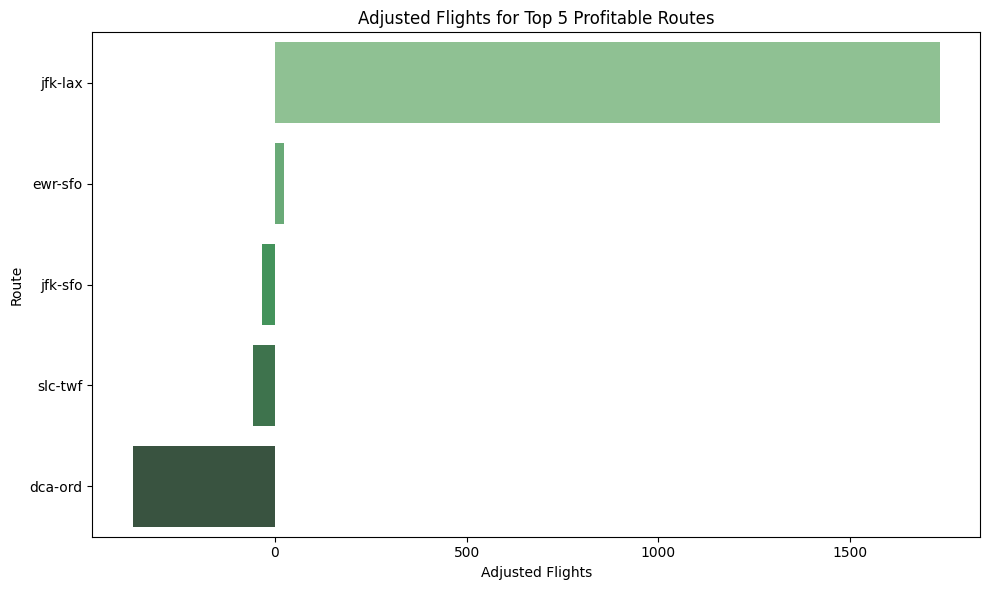

In [101]:
# calculating the flights which are above or below breakeven
top_5_profitable_routes['adjusted_flights'] = top_5_profitable_routes['round_trips'] - top_5_profitable_routes['breakeven_flights']
top_5_profitable_routes[['route_key', 'round_trips', 'breakeven_flights', 'adjusted_flights']]
display(top_5_profitable_routes[['route_key', 'origin_city_name', 'dest_city_name', 'round_trips', 'profit_million','profit_per_trip','breakeven_flights','adjusted_flights']])

# Plotting the adjusted flights for the top 5 profitable routes
plt.figure(figsize=(10, 6))
sns.barplot(
    x='adjusted_flights',
    y='route_key',
    hue='route_key',
    data=top_5_profitable_routes,
    palette='Greens_d',
    legend=False
)
plt.title('Adjusted Flights for Top 5 Profitable Routes')
plt.xlabel('Adjusted Flights')
plt.ylabel('Route')
plt.tight_layout()
plt.show()



<h3>Observations Based on Adjusted Flights</h3>
<ul>
  <li><b>JFK–LAX</b> offers the largest margin with <b>1,734 flights</b> beyond breakeven, making it the most financially secure route.</li>
  <li><b>EWR–SFO</b> barely clears the breakeven threshold, with only <b>24 additional flights</b>, suggesting modest surplus capacity.</li>
  <li>Routes like <b>JFK–SFO</b>, <b>SLC–TWF</b>, and <b>DCA–ORD</b> fall short of breakeven in Q1, indicating potential risk unless operated over a longer period or optimized further.</li>
  <li>This analysis highlights the importance of considering not just profitability, but also the <b>volume required to recoup investment</b>, helping to prioritize routes with better post-investment returns.</li>
</ul>


<h1 style="text-align:center;"><b> Analysis On Top 5 Selected Routes </b> </h1>

In [102]:
top_5_profitable_routes.head()

,route_key,profit_quarter,origin_city_name,dest_city_name,origin_type,dest_type,round_trips,profit_per_trip,avg_dep_delay,avg_arr_delay,profit_million,breakeven_flights,adjusted_flights
0,jfk-lax,2.002884e+08,"New York, NY","Los Angeles, CA",large_airport,large_airport,3149,63603.816070,8.508493,-1.890300,$200.3M,1415.0,1734.0
1,ewr-sfo,9.179655e+07,"San Francisco, CA","Newark, NJ",large_airport,large_airport,1205,76179.712514,21.443799,14.535462,$91.8M,1181.0,24.0
2,jfk-sfo,8.844071e+07,"San Francisco, CA","New York, NY",large_airport,large_airport,1850,47805.786961,15.151351,6.883784,$88.4M,1883.0,-33.0
3,slc-twf,7.525369e+07,"Twin Falls, ID","Salt Lake City, UT",medium_airport,large_airport,290,259495.494044,6.606897,1.118966,$75.3M,347.0,-57.0
4,dca-ord,7.491528e+07,"Washington, DC","Chicago, IL",large_airport,large_airport,1844,40626.505572,10.265456,6.459599,$74.9M,2215.0,-371.0


<h2> Recovery analysis </b>

In [103]:
# Calculating total upfront cost for 5 flights
total_upfront_cost = 90000000 * 5
print(f"Total Upfront Cost for 5 Flights: ${total_upfront_cost / 1_000_000:.1f}M")


Total Upfront Cost for 5 Flights: $450.0M


In [104]:
# Computing the recovery cost
recovery_cost = top_5_profitable_routes['profit_quarter'].sum() - total_upfront_cost
print(f"Total Recovery Cost: ${recovery_cost / 1_000_000:.1f}M")

Total Recovery Cost: $80.7M


<h3> Observation </h3>
<ui>
<p>The company earns a total profit of $80.7M even after covering the $450M upfront cost and other operational costs. This shows that the selected 5 routes are not just profitable, but also a smart and reliable choice for entering the market.</p>
</ui>

<h2> Delay analysis </b>

In [105]:
# Computing Total Delay 
top_5_profitable_routes['total_delay'] = top_5_profitable_routes['avg_arr_delay'] + top_5_profitable_routes['avg_dep_delay']
top_5_profitable_routes.head()

,route_key,profit_quarter,origin_city_name,dest_city_name,origin_type,dest_type,round_trips,profit_per_trip,avg_dep_delay,avg_arr_delay,profit_million,breakeven_flights,adjusted_flights,total_delay
0,jfk-lax,2.002884e+08,"New York, NY","Los Angeles, CA",large_airport,large_airport,3149,63603.816070,8.508493,-1.890300,$200.3M,1415.0,1734.0,6.618193
1,ewr-sfo,9.179655e+07,"San Francisco, CA","Newark, NJ",large_airport,large_airport,1205,76179.712514,21.443799,14.535462,$91.8M,1181.0,24.0,35.979262
2,jfk-sfo,8.844071e+07,"San Francisco, CA","New York, NY",large_airport,large_airport,1850,47805.786961,15.151351,6.883784,$88.4M,1883.0,-33.0,22.035135
3,slc-twf,7.525369e+07,"Twin Falls, ID","Salt Lake City, UT",medium_airport,large_airport,290,259495.494044,6.606897,1.118966,$75.3M,347.0,-57.0,7.725862
4,dca-ord,7.491528e+07,"Washington, DC","Chicago, IL",large_airport,large_airport,1844,40626.505572,10.265456,6.459599,$74.9M,2215.0,-371.0,16.725054


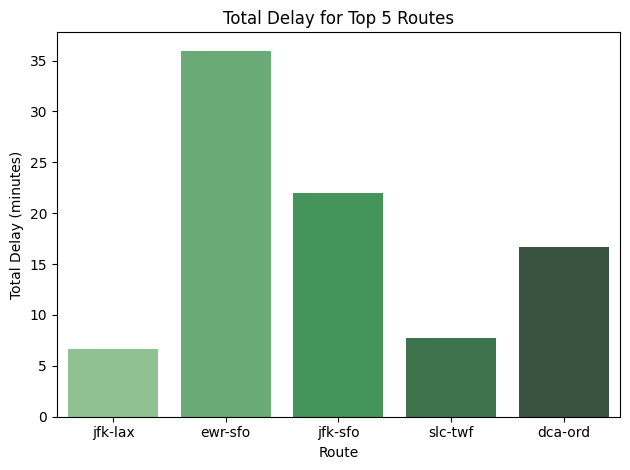

In [106]:
#Plotting the total delay 
sns.barplot(
    x='route_key',
    y='total_delay',
    hue='route_key',
    data= top_5_profitable_routes,
    palette='Greens_d',
    legend=False
)
plt.title('Total Delay for Top 5 Routes')
plt.ylabel('Total Delay (minutes)')
plt.xlabel('Route')
plt.tight_layout()
plt.show()

<h3>Observation</h3>
<p>
Since the company’s motto is <strong>“On time, for you,”</strong> staying punctual is a top priority. Based on the delay analysis, three of the selected routes:- <strong>EWR-SFO</strong>, <strong>JFK-SFO</strong>, and <strong>DCA-ORD</strong> have average delays over 15 minutes. 
</p>
<p>
While a few minutes of delay might be acceptable at most airports, consistently going over this threshold could affect the company’s reputation for reliability. It's a good idea to keep a closer eye on these routes and work on improving their on-time performance to stay aligned with the company’s promise to its customers.
</p>


<h1 style="text-align:center;">Key Business Insights</h1>

<p>
Based on the analysis of over 2,700 domestic round-trip routes, the selected top 5 routes demonstrate strong financial performance, with a total quarterly profit of <strong>$531M</strong>. After accounting for the <strong>$450M upfront investment</strong> in new aircraft, the company still achieves a net gain of <strong>$80.7M</strong>, reinforcing the decision to move forward with these routes.
</p>

<p>
The <strong>adjusted flights metric</strong> shows that two routes:- <strong>JFK-LAX</strong> and <strong>EWR-SFO</strong> operate well above their breakeven thresholds. This creates a healthy profit buffer, offering flexibility to absorb demand shifts, operational delays, or implement competitive pricing strategies without risking capital recovery.
</p>

<p>
However, as the company’s motto is <strong>“On time, for you,”</strong> punctuality must remain a priority. Three selected routes:- <strong>EWR–SFO</strong>, <strong>JFK–SFO</strong>, and <strong>DCA–ORD</strong> show average delays above 15 minutes. While a few minutes may be tolerated operationally, consistently exceeding this benchmark can affect the brand's reliability perception. Monitoring and improving delay performance on these routes is recommended.
</p>

<p>
Going forward, the company should continue to track key performance indicators such as <strong>profit per trip</strong>, <strong>occupancy rate</strong>, and <strong>delay trends</strong>. The optimization and scoring models developed in this analysis can also be reused as a framework to evaluate future route opportunities.
</p>

<p>
In summary, the selected routes offer not just profitability but strategic resilience, making them a sound investment for entering and scaling in the U.S. Airline market.
</p>
